# Lab Day 1 — Xây dựng mạng nơ-ron và thí nghiệm huấn luyện

**MSSV: 2A202602571** · Track 4 · Ngày 1 · VinUniversity AICB 2026

Notebook làm việc tại `submission_2A202602571/code/`. Code nằm trong 6 module cùng thư mục; notebook chỉ gọi `run_experiment(cfg, data)` với các dict cấu hình khác nhau.
Mọi lựa chọn (lr, bộ tối ưu, kiến trúc, epoch) dựa trên **val**; tập eval chỉ xuất hiện ở Part 4, sau khi cấu hình cuối đã chốt.

In [1]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, time, math, subprocess
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from IPython.display import Image, display

REPO_ROOT = "../.."     # thư mục gốc repo (chứa data/ và scripts/), tính từ submission_<MSSV>/code/
OUT_DIR   = ".."        # nơi ghi figures/, results/, experiments.xlsx, predictions_eval.csv (= submission_<MSSV>/)
# Colab: nếu chưa có repo, bỏ comment 2 dòng dưới, rồi đặt REPO_ROOT = "/content/K4-Track4-Day1-Neuralnetwork"
# !git clone https://github.com/VinUni-AI20k/K4-Track4-Day1-Neuralnetwork.git
# REPO_ROOT = "/content/K4-Track4-Day1-Neuralnetwork"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0), "| bf16 supported:", torch.cuda.is_bf16_supported())
os.makedirs(f"{OUT_DIR}/figures", exist_ok=True)
os.makedirs(f"{OUT_DIR}/results", exist_ok=True)
SUBPROC_ENV = {**os.environ, "PYTHONIOENCODING": "utf-8", "PYTHONUTF8": "1"}   # script của repo in tiếng Việt

from data import prepare_data
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import DEFAULT_CFG, set_seed, evaluate, predict, compute_loss, run_experiment, final_eval
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, sort_rows, write_xlsx
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 30)

torch 2.14.0+cu126 | device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU | bf16 supported: True


## Part 0 — Dữ liệu
Chia sẵn bằng metadata: `scripts/split_data.py` tạo `data/processed/train.npz`, `eval.npz`. Sau đó tách validation 20% từ train (phân tầng, seed 42), chuẩn hoá 10 cột số bằng thống kê của phần train còn lại, đưa toàn bộ lên device.

In [2]:
proc_dir = f"{REPO_ROOT}/data/processed"
if not (os.path.exists(f"{proc_dir}/train.npz") and os.path.exists(f"{proc_dir}/eval.npz")):
    out = subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, check=True, env=SUBPROC_ENV,
                         capture_output=True, text=True, encoding="utf-8")
    print(out.stdout)
else:
    print("đã có", proc_dir, "(train.npz, eval.npz) -> không chia lại")

data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=proc_dir)
assert len(data["X_tr"]) == 371_847 and len(data["X_val"]) == 92_962 and len(data["X_eval"]) == 116_203
num = data["X_tr"][:, :10]
print("10 cột số trên X_tr  mean:", np.round(num.mean(0).cpu().numpy(), 4))
print("                     std :", np.round(num.std(0).cpu().numpy(), 4))
print("44 cột nhị phân chỉ gồm 0/1:", bool(((data["X_tr"][:, 10:] == 0) | (data["X_tr"][:, 10:] == 1)).all()))
MAJ_ACC = data["majority_val_acc"]
print(f"mốc thấp nhất phải vượt: accuracy val của 'luôn đoán lớp đa số' = {MAJ_ACC:.4f}")

train: X (464809, 54) float32, y (464809,) int64, nhãn 0..6 -> data\processed\train.npz
eval : X (116203, 54) float32, y (116203,) int64, nhãn 0..6 -> data\processed\eval.npz

lớp   train(%)   eval(%)
  0    36.461    36.460
  1    48.760    48.760
  2     6.154     6.154
  3     0.473     0.472
  4     1.634     1.634
  5     2.989     2.989
  6     3.530     3.530

đoán luôn lớp đa số (lớp 1) cho accuracy trên eval = 0.4876



train (sau tách val): (371847, 54)   val: (92962, 54)   eval: (116203, 54)
tỉ lệ lớp (%)  train: [36.46 48.76  6.15  0.47  1.63  2.99  3.53]
               val  : [36.46 48.76  6.15  0.47  1.63  2.99  3.53]
luôn đoán lớp đa số (lớp 1) -> accuracy trên val = 0.4876


10 cột số trên X_tr  mean: [-0. -0.  0.  0.  0.  0. -0. -0. -0.  0.]
                     std : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
44 cột nhị phân chỉ gồm 0/1: True
mốc thấp nhất phải vượt: accuracy val của 'luôn đoán lớp đa số' = 0.4876


**Nhận xét Part 0.** Kích thước các tập khớp GUIDE (371 847 / 92 962 / 116 203), tỉ lệ lớp ở train và val gần như bằng nhau nhờ tách phân tầng. Trung bình/độ lệch chuẩn của 10 cột số trên phần train còn lại ≈ 0/1. `mean`, `std` chỉ được tính từ `X_tr`: nếu tính trên val hay eval thì thống kê của dữ liệu dùng để chấm đã lọt vào tiền xử lý (rò rỉ), điểm val/eval không còn là ước lượng trung thực. `X_eval` được chuẩn hoá bằng cùng `mean/std` đó và không được dùng ở bất kỳ ô nào trước Part 4.

## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
Quy định: `M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model.

In [3]:
# --- 1. model + assert số tham số
set_seed(1)
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
assert count_params(model) == EXPECTED_PARAMS[(256, 128)] == 47_879
for h, n in EXPECTED_PARAMS.items():
    assert count_params(MLP(hidden=h)) == n
print(model)
print("số tham số M-base:", count_params(model), "| M-wide:", EXPECTED_PARAMS[(512, 256)], "| M-deep:", EXPECTED_PARAMS[(256, 128, 64)])

# --- 2. một lô (8, 54): shape sau từng lớp
x = torch.randn(8, 54, device=device); h = x
print("\nđầu vào".ljust(34), tuple(h.shape))
with torch.no_grad():
    for i, layer in enumerate(model.net):
        h = layer(h); print(f"  net[{i}] {str(layer)[:26]:<26}", tuple(h.shape))
assert h.shape == (8, 7)
# không có softmax trong model: tổng theo hàng của đầu ra không bằng 1
print("tổng theo hàng của logits (không phải 1 => không có softmax):", np.round(h.sum(1)[:3].cpu().numpy(), 3))

# --- 3. loss bước 0 trên val (eval mode), trước mọi cập nhật
ev0 = evaluate(model, data["X_val"], data["y_val"], "ce")
with torch.no_grad():
    logit_std = model(data["X_val"][:8192]).std().item()
print(f"\nloss bước 0 (CE, val) = {ev0['loss']:.4f}   | ln 7 = {math.log(7):.4f}   | lệch = {ev0['loss'] - math.log(7):+.4f}")
print(f"độ lệch chuẩn của logits ở bước 0 = {logit_std:.3f}   | acc bước 0 = {ev0['acc']:.4f}")

MLP(
  (net): Sequential(
    (0): Linear(in_features=54, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=128, out_features=7, bias=True)
  )
)
số tham số M-base: 47879 | M-wide: 161287 | M-deep: 55687

đầu vào                           (8, 54)


  net[0] Linear(in_features=54, out (8, 256)
  net[1] ReLU()                     (8, 256)
  net[2] Dropout(p=0.0, inplace=Fal (8, 256)
  net[3] Linear(in_features=256, ou (8, 128)
  net[4] ReLU()                     (8, 128)
  net[5] Dropout(p=0.0, inplace=Fal (8, 128)
  net[6] Linear(in_features=128, ou (8, 7)
tổng theo hàng của logits (không phải 1 => không có softmax): [-5.064 -3.925 -6.75 ]



loss bước 0 (CE, val) = 2.2691   | ln 7 = 1.9459   | lệch = +0.3232


độ lệch chuẩn của logits ở bước 0 = 0.577   | acc bước 0 = 0.0283


nhãn của 20 mẫu: [1, 0, 1, 0, 1, 6, 0, 0, 1, 1, 2, 0, 1, 6, 0, 0, 1, 5, 5, 0]
loss bước 1 = 2.3493 -> bước 300 = 2.33e-04;  accuracy trên 20 mẫu = 1.00
đạt accuracy 100% lần đầu ở bước 10


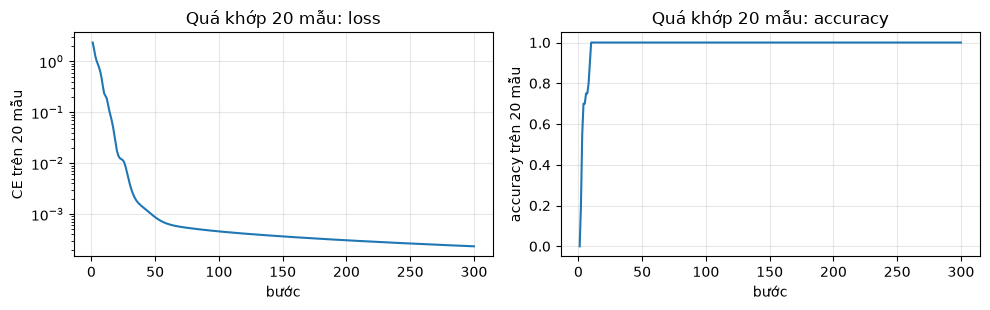

  W1 (net.0.weight) shape (256, 54)   ‖grad‖ = 0.5071
  b1 (net.0.bias  ) shape (256,)      ‖grad‖ = 0.3422
  W2 (net.3.weight) shape (128, 256)  ‖grad‖ = 2.0212
  b2 (net.3.bias  ) shape (128,)      ‖grad‖ = 0.4439
  W3 (net.6.weight) shape (7, 128)    ‖grad‖ = 1.9605
  b3 (net.6.bias  ) shape (7,)        ‖grad‖ = 0.5725
chuẩn toàn cục: 2.9711 -> mọi tham số có gradient khác None và khác 0


In [4]:
# --- 4. quá khớp 20 mẫu (dropout = 0, không regularization), cùng model He ở trên
set_seed(1)
idx = torch.randperm(len(data["X_tr"]), device=data["X_tr"].device)[:20]
xs, ys = data["X_tr"][idx], data["y_tr"][idx]
m20 = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
opt20 = build_optimizer("sgd_momentum", m20.parameters(), lr=0.05)
losses, accs = [], []
m20.train()
for step in range(300):
    logits = m20(xs); loss = compute_loss(logits, ys, "ce")
    opt20.zero_grad(set_to_none=True); loss.backward(); opt20.step()
    losses.append(loss.item()); accs.append((logits.argmax(1) == ys).float().mean().item())
print("nhãn của 20 mẫu:", ys.tolist())
print(f"loss bước 1 = {losses[0]:.4f} -> bước 300 = {losses[-1]:.2e};  accuracy trên 20 mẫu = {accs[-1]:.2f}")
first100 = next(i + 1 for i, a in enumerate(accs) if a == 1.0)
print("đạt accuracy 100% lần đầu ở bước", first100)
assert losses[-1] < 1e-2 and accs[-1] == 1.0

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].plot(range(1, 301), losses); ax[0].set_yscale("log"); ax[0].set_xlabel("bước"); ax[0].set_ylabel("CE trên 20 mẫu"); ax[0].set_title("Quá khớp 20 mẫu: loss"); ax[0].grid(alpha=.3)
ax[1].plot(range(1, 301), accs); ax[1].set_xlabel("bước"); ax[1].set_ylabel("accuracy trên 20 mẫu"); ax[1].set_title("Quá khớp 20 mẫu: accuracy"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

# --- 5. gradient có chảy tới mọi tham số không? (một lô 512, một lần backward)
set_seed(1)
mg = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
loss = compute_loss(mg(data["X_tr"][:512]), data["y_tr"][:512], "ce"); loss.backward()
names = ["W1", "b1", "W2", "b2", "W3", "b3"]
for nm, (pn, p) in zip(names, mg.named_parameters()):
    assert p.grad is not None and p.grad.norm().item() > 0, pn
    print(f"  {nm} ({pn:<12}) shape {str(tuple(p.shape)):<11} ‖grad‖ = {p.grad.norm().item():.4f}")
print("chuẩn toàn cục:", round(clip_gradients(mg.parameters(), None), 4), "-> mọi tham số có gradient khác None và khác 0")

**Nhận xét Part 1.** Model có đúng 47 879 tham số, một lô `(8, 54)` cho ra `(8, 7)`, và tổng theo hàng của đầu ra khác 1 nên không có softmax trong model.
- **Loss bước 0 đo được = 2,2691**, cao hơn `ln 7 = 1,9459` là **+0,323**. Đây không phải lỗi nhãn hay softmax hai lần: khởi tạo He áp dụng cho cả lớp cuối (`Var = 2/128`) nên logit ở bước 0 có độ lệch chuẩn ≈ 0,58 chứ không bằng 0, và model "tự tin sai" một chút (accuracy bước 0 chỉ 2,8%). Bằng chứng: với `normal` (logit ≈ 0) loss bước 0 là 1,9460, với `zeros` đúng bằng 1,9459 (bảng ở Chủ đề 7); seed 2 và 3 của baseline cho 1,978 và 1,900. Độ lệch phụ thuộc seed và nằm trong khoảng 1,90–2,27, tức cùng cỡ với `ln 7`, không phải dấu hiệu "điểm số lớp cuối quá lớn" theo bảng triệu chứng của GUIDE.
- **Quá khớp 20 mẫu:** loss từ 2,35 về 2,3·10⁻⁴ sau 300 bước, accuracy 100% từ bước 10. Model, hàm mất mát, `zero_grad` và optimizer phối hợp đúng. Phép thử này chỉ chứng minh vòng cập nhật chạy, chưa nói gì về tổng quát hoá.
- **Gradient:** cả 6 tham số `W1, b1, W2, b2, W3, b3` có gradient khác `None` và khác 0 (chuẩn từ 0,34 đến 2,02; toàn cục 2,97).

## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` nhận một dict cấu hình và trả về `cfg`, `history`, `summary`, `best_state`. Baseline: `M-base`, He, CE, SGD + momentum 0,9, weight decay 0, batch 512, 20 epoch, dropout 0, không clip, FP32.

Ô dưới định nghĩa hàm bọc `run(cfg)`: chạy → lưu `results/<exp_id>.json` → lưu `figures/<exp_id>.png` ngay sau mỗi lần chạy.

In [5]:
RES = {}     # exp_id -> result (giữ best_state trong RAM cho Part 4)

def failed_result(cfg, reason):
    """Cấu hình không chạy được trên thiết bị này (ví dụ fp16 khi không có CUDA): vẫn giữ một dòng + lý do."""
    hist = {k: [] for k in ("epoch", "train_loss", "val_loss", "val_acc", "val_macro_f1", "grad_norm", "grad_norm_max", "epoch_time_s")}
    return dict(cfg={**DEFAULT_CFG, **cfg}, history=hist, summary=dict(diverged=False, not_run=True), best_state=None,
                notes=f"KHÔNG CHẠY ĐƯỢC: {reason}")

def run(cfg, notes=""):
    t0 = time.time()
    try:
        r = run_experiment(cfg, data, verbose=False); r["notes"] = notes
    except RuntimeError as e:
        r = failed_result(cfg, str(e)); r["notes"] += ("; " + notes if notes else "")
    eid = r["cfg"]["exp_id"]; assert eid not in RES, f"exp_id trùng: {eid}"
    save_result(r, f"{OUT_DIR}/results"); plot_run(r, f"{OUT_DIR}/figures/{eid}.png"); RES[eid] = r
    s = r["summary"]
    if s.get("not_run"):
        print(f"{eid:<18} {r['notes']}")
    elif s["best_epoch"] is None:
        print(f"{eid:<18} DIVERGED ({s['diverged_at']})")
    else:
        print(f"{eid:<18} best_ep {s['best_epoch']:>2}  val_loss {s['best_val_loss']:.4f}  train_loss(cuối) {s['final_train_loss']:.4f}  "
              f"acc {s['val_acc']:.4f}  f1 {s['val_macro_f1']:.4f}  gn_p50 {s['grad_norm_p50']:.3f}  {s['time_per_epoch_s']:.2f}s/ep"
              f"{'  DIVERGED' if s['diverged'] else ''}  (tổng {time.time() - t0:.0f}s)")
    return r

def f1_of(eid):
    v = RES[eid]["summary"].get("val_macro_f1"); return -1.0 if v is None else v

def table(ids):
    """Bảng tóm tắt; Δf1 so với trung bình baseline và cờ vượt 2σ (khi đã có baseline nhiều seed)."""
    rows = []
    for e in ids:
        c, s = RES[e]["cfg"], RES[e]["summary"]
        row = dict(exp_id=e, opt=c["optimizer"], lr=c["lr"], batch=c["batch"], epochs=c["epochs"], best_ep=s.get("best_epoch"),
                   step0=s.get("step0_loss"), train_loss=s.get("final_train_loss"), val_loss=s.get("best_val_loss"),
                   val_acc=s.get("val_acc"), val_f1=s.get("val_macro_f1"), s_per_ep=s.get("time_per_epoch_s"),
                   mem_MB=s.get("peak_mem_MB"), steps=s.get("total_steps"), diverged=s.get("diverged"))
        if "BASE_F1_MEAN" in globals() and s.get("val_macro_f1") is not None:
            row["d_f1_vs_base"] = s["val_macro_f1"] - BASE_F1_MEAN
            row["vượt_2σ"] = abs(row["d_f1_vs_base"]) > NOISE_2S
        rows.append(row)
    return pd.DataFrame(rows).set_index("exp_id").round(4)

### 2a. Chọn learning rate cho baseline bằng val
**Dự đoán trước:** với SGD + momentum 0,9, bước hiệu dụng xấp xỉ `lr/(1−0,9) = 10·lr`. Tôi dự đoán `lr = 0,01` học chậm (20 epoch chưa đủ, val loss còn cao), `lr = 0,3` dao động mạnh ở val, và giá trị tốt nằm quanh `0,03–0,1`. Lưới gồm thêm `lr = 1,0` để giá trị tốt nhất không nằm ở mép lưới; tôi dự đoán nó dao động hoặc hỏng. Năm lần thử này thuộc nhóm `hparam` (yếu tố đổi duy nhất là lr) và đều có dòng trong bảng.

hp-lr0.01          best_ep 20  val_loss 0.3125  train_loss(cuối) 0.3013  acc 0.8722  f1 0.7625  gn_p50 0.994  1.21s/ep  (tổng 26s)


hp-lr0.03          best_ep 19  val_loss 0.2632  train_loss(cuối) 0.2524  acc 0.8939  f1 0.8206  gn_p50 0.904  1.17s/ep  (tổng 25s)


hp-lr0.1           best_ep 19  val_loss 0.2328  train_loss(cuối) 0.2180  acc 0.9051  f1 0.8476  gn_p50 0.548  1.59s/ep  (tổng 34s)


hp-lr0.3           best_ep 19  val_loss 0.2227  train_loss(cuối) 0.2030  acc 0.9093  f1 0.8513  gn_p50 0.345  1.17s/ep  (tổng 25s)


hp-lr1             best_ep 18  val_loss 0.3442  train_loss(cuối) 0.3912  acc 0.8645  f1 0.7701  gn_p50 0.242  1.04s/ep  (tổng 22s)


,opt,lr,batch,epochs,best_ep,step0,train_loss,val_loss,val_acc,val_f1,s_per_ep,mem_MB,steps,diverged
exp_id,,,,,,,,,,,,,,
hp-lr0.01,sgd_momentum,0.01,512,20,20,2.2691,0.3013,0.3125,0.8722,0.7625,1.2113,164.9575,14540,False
hp-lr0.03,sgd_momentum,0.03,512,20,19,2.2691,0.2524,0.2632,0.8939,0.8206,1.1733,165.1406,14540,False
hp-lr0.1,sgd_momentum,0.10,512,20,19,2.2691,0.2180,0.2328,0.9051,0.8476,1.5860,165.3237,14540,False
hp-lr0.3,sgd_momentum,0.30,512,20,19,2.2691,0.2030,0.2227,0.9093,0.8513,1.1741,165.5068,14540,False
hp-lr1,sgd_momentum,1.00,512,20,18,2.2691,0.3912,0.3442,0.8645,0.7701,1.0427,165.6899,14540,False


lr được chọn cho baseline (theo val macro-F1): 0.3


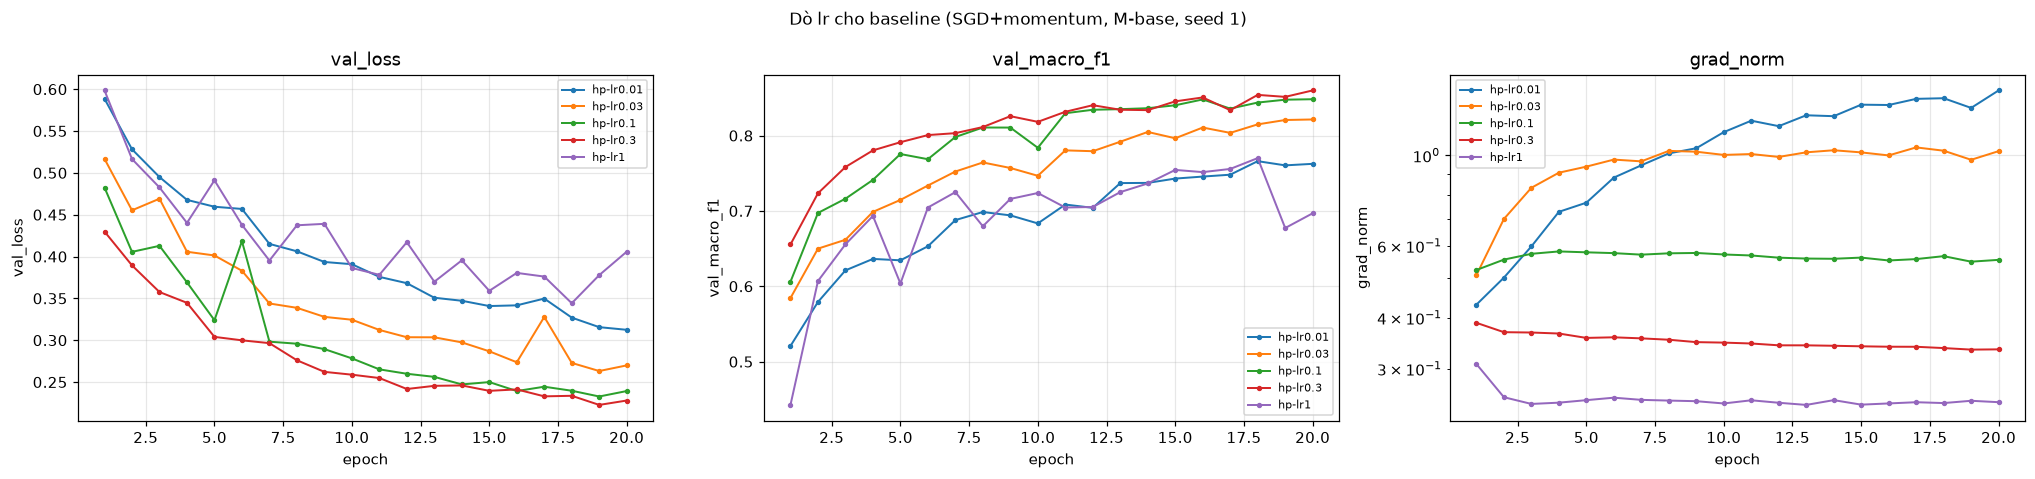

In [6]:
LR_GRID = [0.01, 0.03, 0.1, 0.3, 1.0]
for lr in LR_GRID:
    run({**DEFAULT_CFG, "exp_id": f"hp-lr{lr:g}", "group": "hparam", "description": f"Baseline nhưng lr={lr:g} (dò lr)", "lr": lr},
        notes="dò lr cho baseline; chỉ đổi lr")
LR_IDS = [f"hp-lr{lr:g}" for lr in LR_GRID]
display(table(LR_IDS))
BASE_LR = RES[max(LR_IDS, key=f1_of)]["cfg"]["lr"]      # tiêu chí: val macro-F1 tại epoch có val loss thấp nhất
print("lr được chọn cho baseline (theo val macro-F1):", BASE_LR)
plot_compare([RES[e] for e in LR_IDS], ["val_loss", "val_macro_f1", "grad_norm"], f"{OUT_DIR}/figures/compare_lr.png",
             "Dò lr cho baseline (SGD+momentum, M-base, seed 1)")
display(Image(f"{OUT_DIR}/figures/compare_lr.png"))

**Đối chiếu sau khi chạy:** dự đoán đúng một nửa. `lr = 0,01` đúng là chậm (`hp-lr0.01`: val macro-F1 0,7625, train loss 0,301 còn cao) và `lr = 1,0` hỏng rõ (`hp-lr1`: 0,7701, macro-F1 nhảy lên xuống giữa các epoch, ví dụ 0,770 → 0,677 ở epoch 18 → 19). Nhưng giá trị tốt nhất là **`lr = 0,3`** (`hp-lr0.3`: 0,8513), cao hơn vùng 0,03–0,1 tôi dự đoán; ở 0,3 val loss vẫn giảm đều chứ chưa dao động mạnh. Chênh lệch giữa 0,3 và 0,1 (`hp-lr0.1`: 0,8476) chỉ 0,0037, nhỏ hơn ngưỡng nhiễu 2σ = 0,0095 đo ở ô sau, nên chỉ kết luận được "lr tốt nằm trong khoảng 0,1–0,3"; tôi lấy 0,3 theo đúng quy tắc đã đặt (val macro-F1 cao nhất). Tối ưu nằm bên trong lưới (0,1 < 0,3 < 1,0), không ở mép. `grad_norm` trung bình giảm khi lr tăng từ 0,01 đến 0,3: lr lớn đưa mô hình nhanh hơn tới vùng loss thấp, nơi gradient nhỏ.

### 2b. Baseline với 3 seed và độ nhiễu
Chạy cấu hình baseline ở lr vừa chọn với seed 1, 2, 3. Seed đổi cả khởi tạo lẫn thứ tự xáo lô; phép tách val giữ nguyên (seed 42).

base-s1            best_ep 19  val_loss 0.2227  train_loss(cuối) 0.2030  acc 0.9093  f1 0.8513  gn_p50 0.345  1.04s/ep  (tổng 22s)


base-s2            best_ep 20  val_loss 0.2236  train_loss(cuối) 0.1972  acc 0.9119  f1 0.8609  gn_p50 0.338  1.05s/ep  (tổng 23s)


base-s3            best_ep 19  val_loss 0.2174  train_loss(cuối) 0.1997  acc 0.9129  f1 0.8567  gn_p50 0.344  1.05s/ep  (tổng 23s)


,opt,lr,batch,epochs,best_ep,step0,train_loss,val_loss,val_acc,val_f1,s_per_ep,mem_MB,steps,diverged
exp_id,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.3,512,20,19,2.2691,0.2030,0.2227,0.9093,0.8513,1.0359,165.8730,14540,False
base-s2,sgd_momentum,0.3,512,20,20,1.9782,0.1972,0.2236,0.9119,0.8609,1.0506,166.0562,14540,False
base-s3,sgd_momentum,0.3,512,20,19,1.9005,0.1997,0.2174,0.9129,0.8567,1.0550,166.2393,14540,False


val macro-F1 : 0.8563 ± 0.0048   -> ngưỡng nhiễu 2σ = 0.0095
val accuracy : 0.9114 ± 0.0019   (2σ = 0.0038)
best val loss: 0.2212 ± 0.0034
mốc đoán lớp đa số: acc 0.4876  -> baseline vượt mốc: True
base-s1: step0 loss 2.2691; grad_norm mỗi bước p50 0.345, p90 0.405, max 3.012
base-s1 train loss 5 epoch cuối: [0.2198 0.2102 0.2122 0.2    0.203 ] 
        val loss   5 epoch cuối: [0.2412 0.2329 0.2336 0.2227 0.2279]


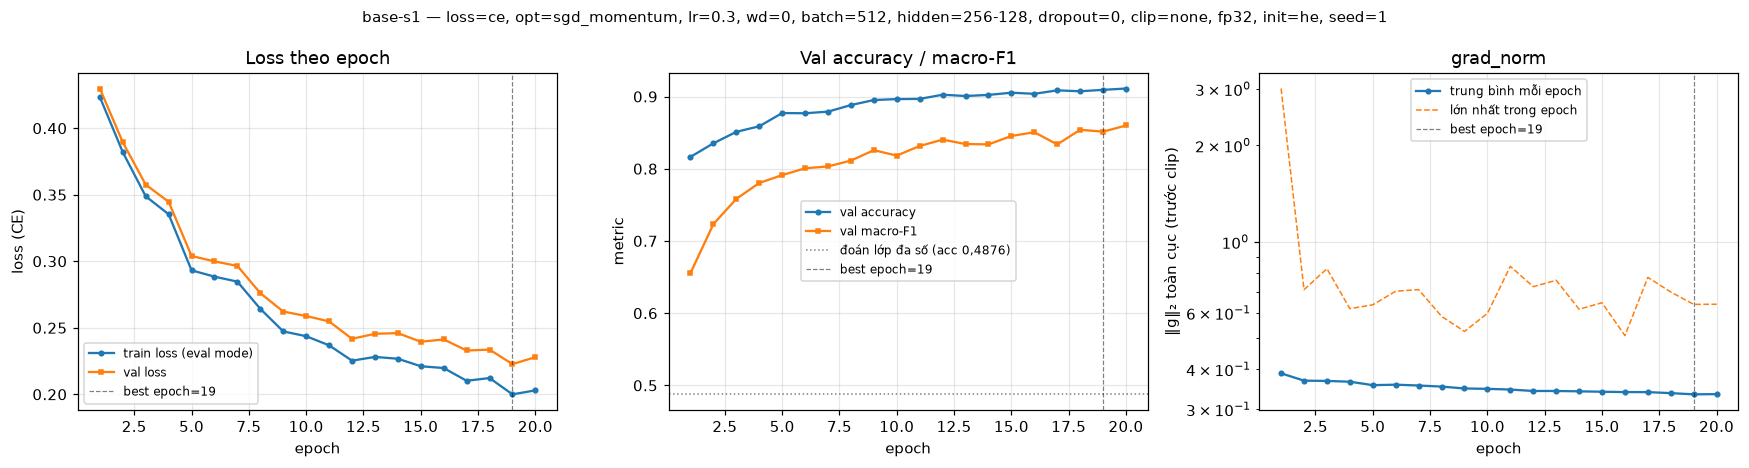

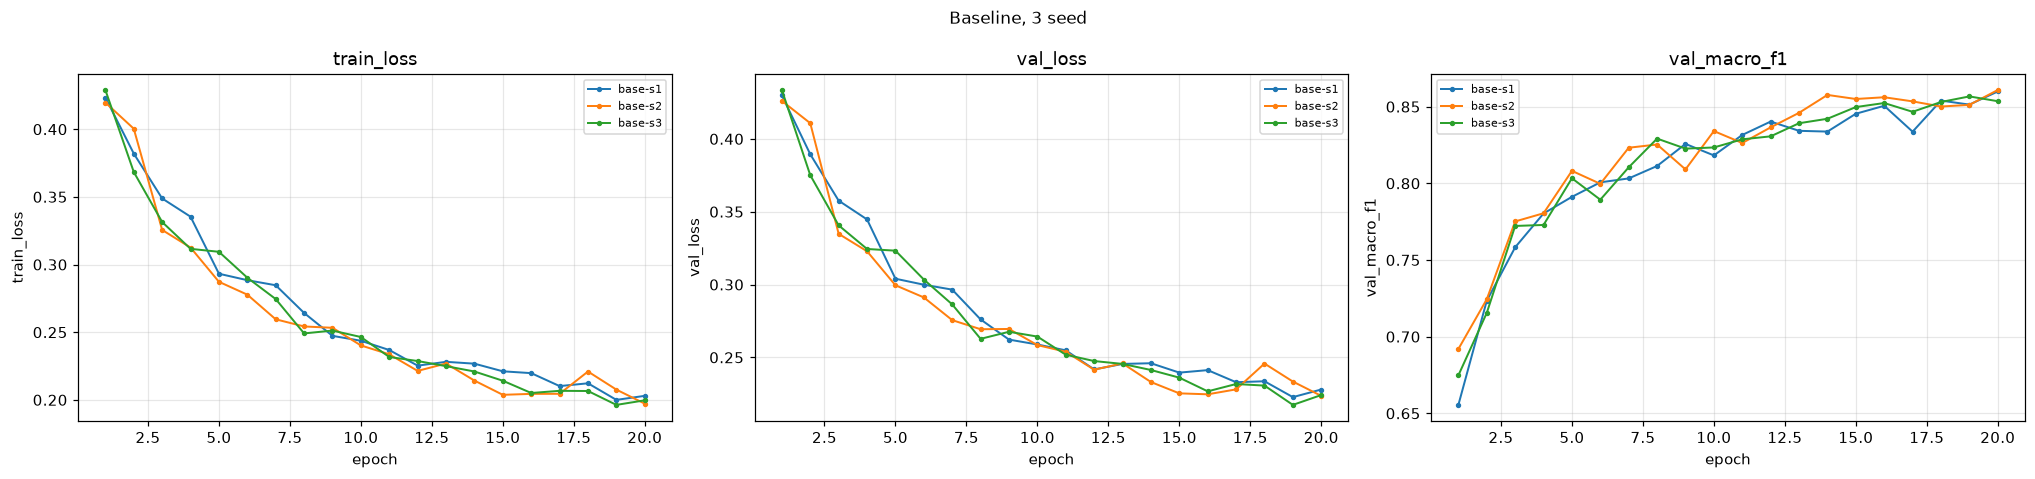

In [7]:
BASE_CFG = {**DEFAULT_CFG, "lr": BASE_LR}
for s in (1, 2, 3):
    run({**BASE_CFG, "exp_id": f"base-s{s}", "seed": s, "description": f"Baseline M-base, seed {s}"})
BASE_IDS = ["base-s1", "base-s2", "base-s3"]
display(table(BASE_IDS))
f1s  = np.array([RES[e]["summary"]["val_macro_f1"] for e in BASE_IDS])
accs_ = np.array([RES[e]["summary"]["val_acc"] for e in BASE_IDS])
vls  = np.array([RES[e]["summary"]["best_val_loss"] for e in BASE_IDS])
BASE_F1_MEAN, BASE_F1_STD = f1s.mean(), f1s.std(ddof=1)      # std mẫu (ddof=1), như STDEV của sheet Seeds
NOISE_2S = 2 * BASE_F1_STD
print(f"val macro-F1 : {BASE_F1_MEAN:.4f} ± {BASE_F1_STD:.4f}   -> ngưỡng nhiễu 2σ = {NOISE_2S:.4f}")
print(f"val accuracy : {accs_.mean():.4f} ± {accs_.std(ddof=1):.4f}   (2σ = {2 * accs_.std(ddof=1):.4f})")
print(f"best val loss: {vls.mean():.4f} ± {vls.std(ddof=1):.4f}")
print(f"mốc đoán lớp đa số: acc {MAJ_ACC:.4f}  -> baseline vượt mốc: {bool((accs_ > MAJ_ACC).all())}")
b1 = RES["base-s1"]
print(f"base-s1: step0 loss {b1['summary']['step0_loss']:.4f}; grad_norm mỗi bước p50 {b1['summary']['grad_norm_p50']:.3f}, "
      f"p90 {b1['summary']['grad_norm_p90']:.3f}, max {b1['summary']['grad_norm_max']:.3f}")
h = b1["history"]
print("base-s1 train loss 5 epoch cuối:", np.round(h["train_loss"][-5:], 4), "\n        val loss   5 epoch cuối:", np.round(h["val_loss"][-5:], 4))
plot_compare([RES[e] for e in BASE_IDS], ["train_loss", "val_loss", "val_macro_f1"], f"{OUT_DIR}/figures/compare_baseline.png", "Baseline, 3 seed")
display(Image(f"{OUT_DIR}/figures/base-s1.png")); display(Image(f"{OUT_DIR}/figures/compare_baseline.png"))

**Nhận xét baseline.** `base-s1/2/3` ở `lr = 0,3`:
- **Hình dạng đường cong:** train loss và val loss cùng giảm suốt 20 epoch, có gợn nhỏ giữa các epoch; best epoch là 19, 20, 19, tức **chưa hội tụ**. Khoảng cách val − train ở epoch cuối của `base-s1` là +0,025 (0,2279 so với 0,2030): rất nhỏ, mô hình đang ở chế độ chưa khớp nhiều hơn là quá khớp.
- **So với mốc:** val accuracy 0,9114 ± 0,0019, vượt xa mốc đoán lớp đa số 0,4876.
- **Độ nhiễu:** val macro-F1 = **0,8563 ± 0,0048** (3 seed, độ lệch chuẩn mẫu) → ngưỡng nhiễu **2σ = 0,0095**. Mọi so sánh ở Part 3 dùng ngưỡng này. Hạn chế: σ ước lượng từ 3 seed là thô. Ngoài ra macro-F1 còn dao động giữa các epoch liền nhau cỡ 0,01–0,02 (ví dụ `base-s1`: 0,851 ở epoch 19, 0,860 ở epoch 20), nên giá trị "tại best epoch" tự nó đã mang nhiễu cùng cỡ.
- `grad_norm` mỗi bước của `base-s1`: trung vị 0,345, p90 0,405, lớn nhất 3,01 (ở epoch 1). Dùng để chọn ngưỡng clip ở Chủ đề 5.

## Part 3 — Thí nghiệm
Mỗi thí nghiệm: **dự đoán trước** → đổi **một** yếu tố so với `base-s1` (cùng tập val, seed 1, 20 epoch, trừ khi ghi khác) → chạy → **đối chiếu**. Bảng dưới mỗi nhóm có cột `d_f1_vs_base` (so với trung bình 3 seed baseline) và `vượt_2σ`.

Lưu ý chung: σ ước lượng từ 3 seed là ước lượng thô; mỗi thí nghiệm chỉ chạy 1 seed nên "vượt 2σ" là điều kiện cần, chưa phải kiểm định chặt.

### Chủ đề 1 — Hàm mất mát: `loss-mse`
**Dự đoán trước:** MSE giữa logit và one-hot (trung bình trên B×7 phần tử, không có hệ số 1/2) cho gradient theo logit là `2(z − y)/7`, nhỏ hơn và tuyến tính theo sai số; CE cho gradient `softmax(z) − y`, không bão hoà khi sai nặng. Ở cùng lr, tôi dự đoán MSE hội tụ chậm hơn và val macro-F1 thấp hơn CE, thiệt nhất ở các lớp hiếm vì MSE kéo logit về 0/1 thay vì tách biên. Không so giá trị loss của hai loại vì khác thang đo.

loss-mse           best_ep 20  val_loss 0.0275  train_loss(cuối) 0.0264  acc 0.8821  f1 0.7888  gn_p50 0.066  1.20s/ep  (tổng 26s)


,opt,lr,batch,epochs,best_ep,step0,train_loss,val_loss,val_acc,val_f1,s_per_ep,mem_MB,steps,diverged,d_f1_vs_base,vượt_2σ
exp_id,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.3,512,20,19,2.2691,0.2030,0.2227,0.9093,0.8513,1.0359,165.8730,14540,False,-0.0050,False
loss-mse,sgd_momentum,0.3,512,20,20,0.6359,0.0264,0.0275,0.8821,0.7888,1.2043,166.4219,14540,False,-0.0675,True


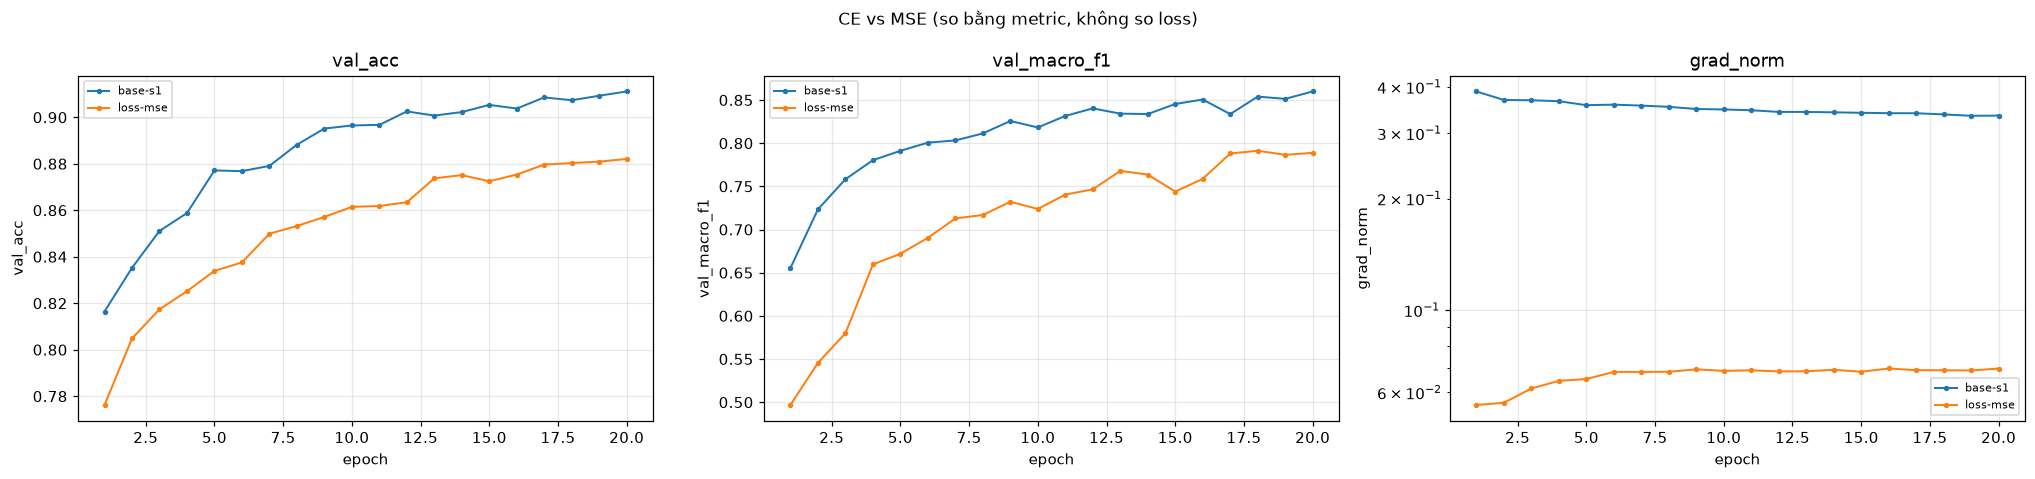

epoch đầu tiên đạt val macro-F1 ≥ 0.710:  CE = 2,  MSE = 7


In [8]:
run({**BASE_CFG, "exp_id": "loss-mse", "group": "loss", "description": "MSE(logit, one-hot) thay cho CE", "loss": "mse"},
    notes="MSE trung bình trên B*7 phần tử, không hệ số 1/2; lr giữ như baseline (chưa dò lại cho MSE)")
display(table(["base-s1", "loss-mse"]))
plot_compare([RES["base-s1"], RES["loss-mse"]], ["val_acc", "val_macro_f1", "grad_norm"], f"{OUT_DIR}/figures/compare_loss.png",
             "CE vs MSE (so bằng metric, không so loss)")
display(Image(f"{OUT_DIR}/figures/compare_loss.png"))
ep_reach = lambda e, thr: next((ep for ep, v in zip(RES[e]["history"]["epoch"], RES[e]["history"]["val_macro_f1"]) if v >= thr), None)
thr = 0.9 * RES["loss-mse"]["summary"]["val_macro_f1"]
print(f"epoch đầu tiên đạt val macro-F1 ≥ {thr:.3f}:  CE = {ep_reach('base-s1', thr)},  MSE = {ep_reach('loss-mse', thr)}")

**Đối chiếu sau khi chạy:** khớp dự đoán. `loss-mse` đạt val macro-F1 0,7888 và accuracy 0,8821, so với 0,8513 và 0,9093 của `base-s1`; thấp hơn trung bình baseline 0,0675, gấp ~7 lần ngưỡng 2σ = 0,0095, nên khác biệt vượt nhiễu. MSE cũng hội tụ chậm hơn: mốc macro-F1 ≥ 0,710 đạt ở epoch 2 với CE nhưng tới epoch 7 với MSE. `grad_norm` trung vị của MSE chỉ 0,067 so với 0,345 của CE, phù hợp với cơ chế: gradient của MSE theo logit là `2(z − y)/7`, bị chia 7 và nhỏ dần khi `z` gần đích, còn CE cho `softmax(z) − y`. Không so 0,0275 (MSE) với 0,2227 (CE) vì khác thang đo. **Hạn chế:** lr = 0,3 được dò cho CE; với gradient nhỏ hơn ~5 lần, MSE có thể cần lr lớn hơn, nên một phần khoảng cách có thể do lr chưa dò lại. Chỉ 1 seed.

### Chủ đề 2 — Bộ tối ưu: SGD, SGD + momentum, Adam, AdamW
**Dự đoán trước:** mỗi bộ được thử 3 lr cách nhau ~3 lần và so ở lr tốt nhất của nó. (i) SGD thuần ở cùng lr sẽ chậm hơn hẳn SGD + momentum, vì momentum 0,9 làm bước hiệu dụng lớn gấp ~10; SGD cần lr lớn nhất trong lưới. (ii) Adam/AdamW quanh `1e-3` sẽ đạt macro-F1 cao hơn SGD + momentum trong 20 epoch nhờ bước theo từng tham số (các cột one-hot đất hiếm khi bật vẫn được cập nhật đủ lớn). (iii) AdamW với `weight_decay = 0,01` gần như trùng Adam: mạng 48k tham số trên 372k mẫu khó quá khớp nên suy giảm trọng số ít tác dụng; chênh lệch sẽ nằm trong nhiễu.

SGD + momentum dùng lại năm lần dò lr ở Part 2 (`hp-lr*`, cùng seed 1).

opt-sgd-lr0.03     best_ep 20  val_loss 0.4273  train_loss(cuối) 0.4204  acc 0.8193  f1 0.6783  gn_p50 0.649  1.05s/ep  (tổng 23s)


opt-sgd-lr0.1      best_ep 18  val_loss 0.3522  train_loss(cuối) 0.3602  acc 0.8532  f1 0.7371  gn_p50 0.813  1.06s/ep  (tổng 23s)


opt-sgd-lr0.3      best_ep 19  val_loss 0.3021  train_loss(cuối) 0.3196  acc 0.8761  f1 0.7746  gn_p50 0.625  1.06s/ep  (tổng 23s)


opt-adam-lr0.0003  best_ep 20  val_loss 0.3090  train_loss(cuối) 0.2974  acc 0.8753  f1 0.7914  gn_p50 0.754  1.22s/ep  (tổng 26s)


opt-adam-lr0.001   best_ep 20  val_loss 0.2417  train_loss(cuối) 0.2222  acc 0.9040  f1 0.8479  gn_p50 0.867  1.30s/ep  (tổng 27s)


...

opt-adamw-lr0.001  best_ep 20  val_loss 0.2447  train_loss(cuối) 0.2271  acc 0.9030  f1 0.8472  gn_p50 0.848  1.26s/ep  (tổng 27s)


opt-adamw-lr0.003  best_ep 20  val_loss 0.2149  train_loss(cuối) 0.1938  acc 0.9140  f1 0.8702  gn_p50 0.631  1.50s/ep  (tổng 32s)


,opt,lr,batch,epochs,best_ep,step0,train_loss,val_loss,val_acc,val_f1,s_per_ep,mem_MB,steps,diverged,d_f1_vs_base,vượt_2σ
exp_id,,,,,,,,,,,,,,,,
hp-lr0.01,sgd_momentum,0.0100,512,20,20,2.2691,0.3013,0.3125,0.8722,0.7625,1.2113,164.9575,14540,False,-0.0938,True
hp-lr0.03,sgd_momentum,0.0300,512,20,19,2.2691,0.2524,0.2632,0.8939,0.8206,1.1733,165.1406,14540,False,-0.0357,True
hp-lr0.1,sgd_momentum,0.1000,512,20,19,2.2691,0.2180,0.2328,0.9051,0.8476,1.5860,165.3237,14540,False,-0.0087,False
hp-lr0.3,sgd_momentum,0.3000,512,20,19,2.2691,0.2030,0.2227,0.9093,0.8513,1.1741,165.5068,14540,False,-0.0050,False
hp-lr1,sgd_momentum,1.0000,512,20,18,2.2691,0.3912,0.3442,0.8645,0.7701,1.0427,165.6899,14540,False,-0.0862,True
opt-sgd-lr0.03,sgd,0.0300,512,20,20,2.2691,0.4204,0.4273,0.8193,0.6783,1.0481,166.4219,14540,False,-0.1780,True
opt-sgd-lr0.1,sgd,0.1000,512,20,18,2.2691,0.3602,0.3522,0.8532,0.7371,1.0615,166.6050,14540,False,-0.1192,True
opt-sgd-lr0.3,sgd,0.3000,512,20,19,2.2691,0.3196,0.3021,0.8761,0.7746,1.0590,166.7881,14540,False,-0.0817,True
opt-adam-lr0.0003,adam,0.0003,512,20,20,2.2691,0.2974,0.3090,0.8753,0.7914,1.2210,167.3374,14540,False,-0.0649,True


lr tốt nhất của mỗi bộ (theo val macro-F1):


,opt,lr,batch,epochs,best_ep,step0,train_loss,val_loss,val_acc,val_f1,s_per_ep,mem_MB,steps,diverged,d_f1_vs_base,vượt_2σ
exp_id,,,,,,,,,,,,,,,,
hp-lr0.3,sgd_momentum,0.300,512,20,19,2.2691,0.2030,0.2227,0.9093,0.8513,1.1741,165.5068,14540,False,-0.0050,False
opt-sgd-lr0.3,sgd,0.300,512,20,19,2.2691,0.3196,0.3021,0.8761,0.7746,1.0590,166.7881,14540,False,-0.0817,True
opt-adam-lr0.003,adam,0.003,512,20,20,2.2691,0.1808,0.2043,0.9191,0.8835,1.2838,167.7036,14540,False,0.0272,True
opt-adamw-lr0.003,adamw,0.003,512,20,20,2.2691,0.1938,0.2149,0.9140,0.8702,1.4963,168.2529,14540,False,0.0139,True


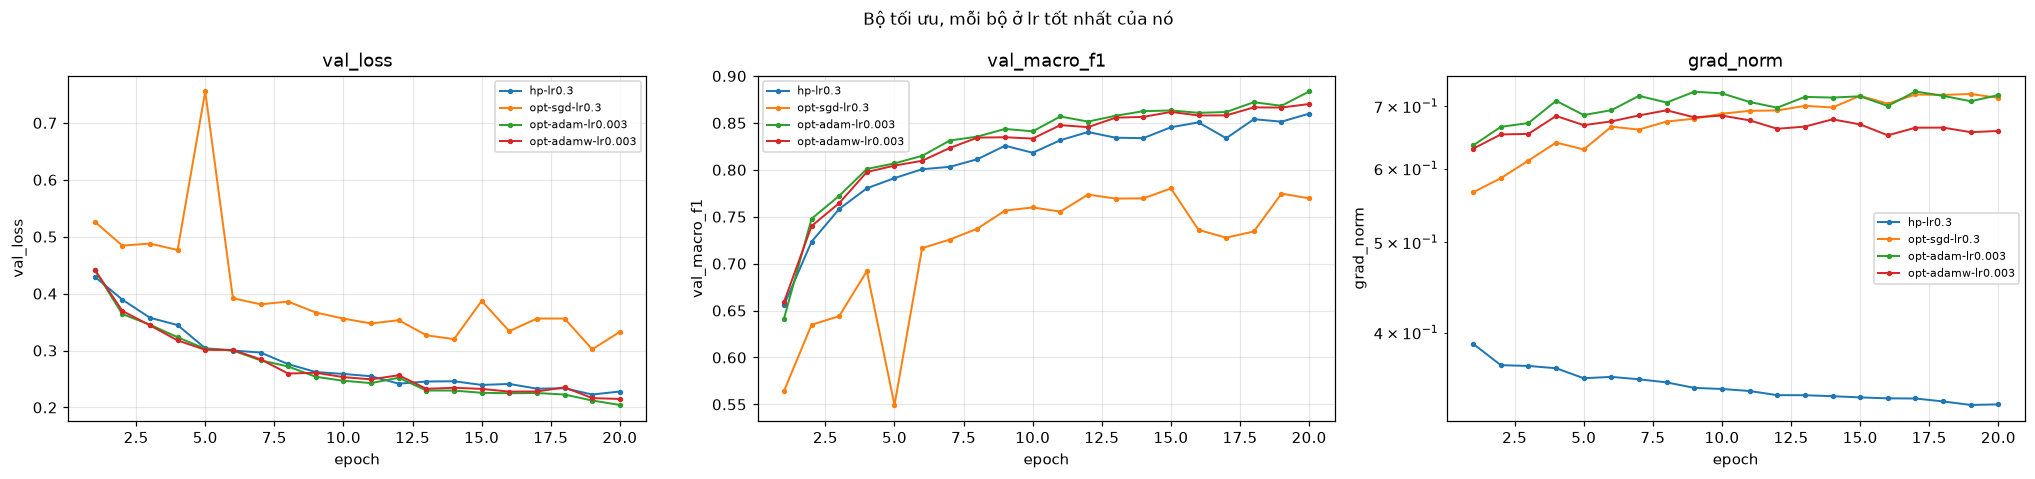

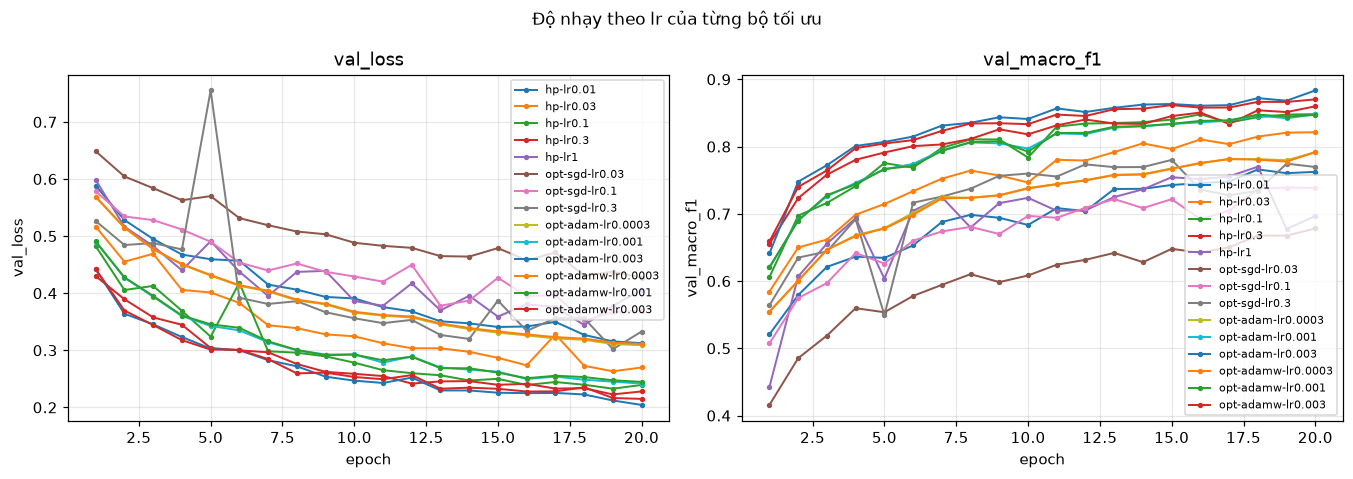

In [9]:
OPT_GRID = {"sgd": [0.03, 0.1, 0.3], "adam": [3e-4, 1e-3, 3e-3], "adamw": [3e-4, 1e-3, 3e-3]}
for name, lrs in OPT_GRID.items():
    for lr in lrs:
        wd = 0.01 if name == "adamw" else 0.0
        run({**BASE_CFG, "exp_id": f"opt-{name}-lr{lr:g}", "group": "optimizer", "optimizer": name, "lr": lr, "weight_decay": wd,
             "description": f"{name}, lr={lr:g}" + (", weight_decay=0.01 (tách riêng)" if wd else "")},
            notes="đổi bộ tối ưu (và lr của riêng nó)" + ("; weight_decay=0.01 đi kèm AdamW" if wd else ""))
OPT_IDS = {"sgd_momentum": LR_IDS, **{n: [f"opt-{n}-lr{lr:g}" for lr in lrs] for n, lrs in OPT_GRID.items()}}
display(table([e for ids in OPT_IDS.values() for e in ids]))
BEST_OF = {n: max(ids, key=f1_of) for n, ids in OPT_IDS.items()}
print("lr tốt nhất của mỗi bộ (theo val macro-F1):")
display(table(list(BEST_OF.values())))
plot_compare([RES[e] for e in BEST_OF.values()], ["val_loss", "val_macro_f1", "grad_norm"], f"{OUT_DIR}/figures/compare_optimizer.png",
             "Bộ tối ưu, mỗi bộ ở lr tốt nhất của nó")
plot_compare([RES[e] for ids in OPT_IDS.values() for e in ids], ["val_loss", "val_macro_f1"], f"{OUT_DIR}/figures/compare_optimizer_lr.png",
             "Độ nhạy theo lr của từng bộ tối ưu")
display(Image(f"{OUT_DIR}/figures/compare_optimizer.png")); display(Image(f"{OUT_DIR}/figures/compare_optimizer_lr.png"))

**Đối chiếu sau khi chạy:** so ở lr tốt nhất của mỗi bộ (val macro-F1): Adam `opt-adam-lr0.003` **0,8835** > AdamW `opt-adamw-lr0.003` 0,8702 > SGD + momentum `hp-lr0.3` 0,8513 > SGD `opt-sgd-lr0.3` 0,7746.
- (i) **Đúng:** SGD thuần kém SGD + momentum 0,077 ở cùng lr 0,3 (vượt xa 2σ) và càng tăng lr càng tốt (0,678 → 0,737 → 0,775), tức lr tốt nhất của SGD còn nằm ngoài mép trên của lưới. Phù hợp với cơ chế: momentum 0,9 cộng dồn gradient nên bước hiệu dụng lớn gấp ~10. Vì vậy SGD ở đây **chưa được dò lr đầy đủ**; con số 0,7746 là cận dưới.
- (ii) **Đúng một phần:** Adam vượt SGD + momentum 0,0322 (`base-s1`) hay +0,0272 so với trung bình baseline, lớn hơn 2σ = 0,0095. Nhưng lr tốt nhất là 3e-3 chứ không phải 1e-3 như tôi nghĩ, và cũng ở mép lưới, nên Adam có thể còn tốt hơn ở lr cao hơn. Train loss của Adam cũng thấp hơn (0,181 so với 0,203), tức Adam tối ưu nhanh hơn trong cùng 14 540 bước chứ không phải tổng quát hoá tốt hơn; phù hợp với việc Adam chuẩn hoá bước theo từng tham số (các cột one-hot loại đất hiếm khi bật có gradient thưa). Đây là giả thuyết về cơ chế, tôi chưa đo riêng gradient của các cột đó.
- (iii) **Chưa kết luận được:** ở lr 3e-4 và 1e-3, Adam và AdamW trùng nhau (0,7914/0,7920 và 0,8479/0,8472). Ở 3e-3 AdamW thấp hơn 0,0133, nhỉnh hơn 2σ một chút. σ được đo trên baseline SGD và mỗi cấu hình chỉ 1 seed, nên tôi không coi đây là bằng chứng chắc rằng weight decay 0,01 có hại.
- **Khi lr không được dò:** Adam ở 1e-3 (0,8479) ngang SGD + momentum ở 0,1 (0,8476); Adam ở 3e-4 (0,7914) thua SGD + momentum ở 0,3 (0,8513) tới 0,06. Kết luận "bộ nào thắng" đảo chiều tuỳ lr.

### Chủ đề 3 — Hyper-parameter: batch size, độ rộng, độ sâu
(Learning rate đã khảo sát ở Part 2: `hp-lr*`.)

**Dự đoán trước:**
- `hp-bs128`: cùng 20 epoch nhưng số bước gấp 4 (≈ 58 100 so với 14 540) và gradient nhiễu hơn → val macro-F1 cao hơn baseline, thời gian mỗi epoch dài hơn nhiều.
- `hp-bs2048`: số bước chỉ còn 1/4 → kém baseline rõ ở cùng lr. `hp-bs2048-lrx4` áp dụng quy tắc tăng lr theo lô (lr × 4, không có khởi động): dự đoán lấy lại phần lớn khoảng cách nếu lr × 4 còn ổn định.
- `hp-wide` (161 287 tham số) và `hp-deep` (55 687 tham số): baseline nhiều khả năng còn chưa khớp (train và val loss sát nhau, cùng còn giảm), nên thêm năng lực sẽ giúp; `M-wide` giúp nhiều hơn `M-deep` vì tăng số tham số gấp 3,4 lần, còn `M-deep` chỉ thêm một lớp 64 hẹp.

hp-bs128           best_ep 16  val_loss 0.3252  train_loss(cuối) 0.3170  acc 0.8739  f1 0.7926  gn_p50 0.433  6.00s/ep  (tổng 123s)


hp-bs2048          best_ep 20  val_loss 0.2415  train_loss(cuối) 0.2205  acc 0.9020  f1 0.8386  gn_p50 0.406  0.36s/ep  (tổng 8s)


hp-bs2048-lrx4     best_ep 20  val_loss 0.3685  train_loss(cuối) 0.3606  acc 0.8505  f1 0.6313  gn_p50 0.203  0.35s/ep  (tổng 9s)


hp-wide            best_ep 20  val_loss 0.1911  train_loss(cuối) 0.1609  acc 0.9238  f1 0.8794  gn_p50 0.341  1.38s/ep  (tổng 30s)


hp-deep            best_ep 19  val_loss 0.2220  train_loss(cuối) 0.1996  acc 0.9132  f1 0.8599  gn_p50 0.370  1.64s/ep  (tổng 35s)


,opt,lr,batch,epochs,best_ep,step0,train_loss,val_loss,val_acc,val_f1,s_per_ep,mem_MB,steps,diverged,d_f1_vs_base,vượt_2σ
exp_id,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.3,512,20,19,2.2691,0.2030,0.2227,0.9093,0.8513,1.0359,165.8730,14540,False,-0.0050,False
hp-bs128,sgd_momentum,0.3,128,20,16,2.2691,0.3170,0.3252,0.8739,0.7926,6.0003,168.2256,58120,False,-0.0637,True
hp-bs2048,sgd_momentum,0.3,2048,20,20,2.2691,0.2205,0.2415,0.9020,0.8386,0.3555,168.6548,3640,False,-0.0177,True
hp-bs2048-lrx4,sgd_momentum,1.2,2048,20,20,2.2691,0.3606,0.3685,0.8505,0.6313,0.3543,168.8379,3640,False,-0.2250,True
hp-wide,sgd_momentum,0.3,512,20,20,1.9182,0.1609,0.1911,0.9238,0.8794,1.3762,186.5327,14540,False,0.0231,True
hp-deep,sgd_momentum,0.3,512,20,19,1.9099,0.1996,0.2220,0.9132,0.8599,1.6405,169.5391,14540,False,0.0036,False


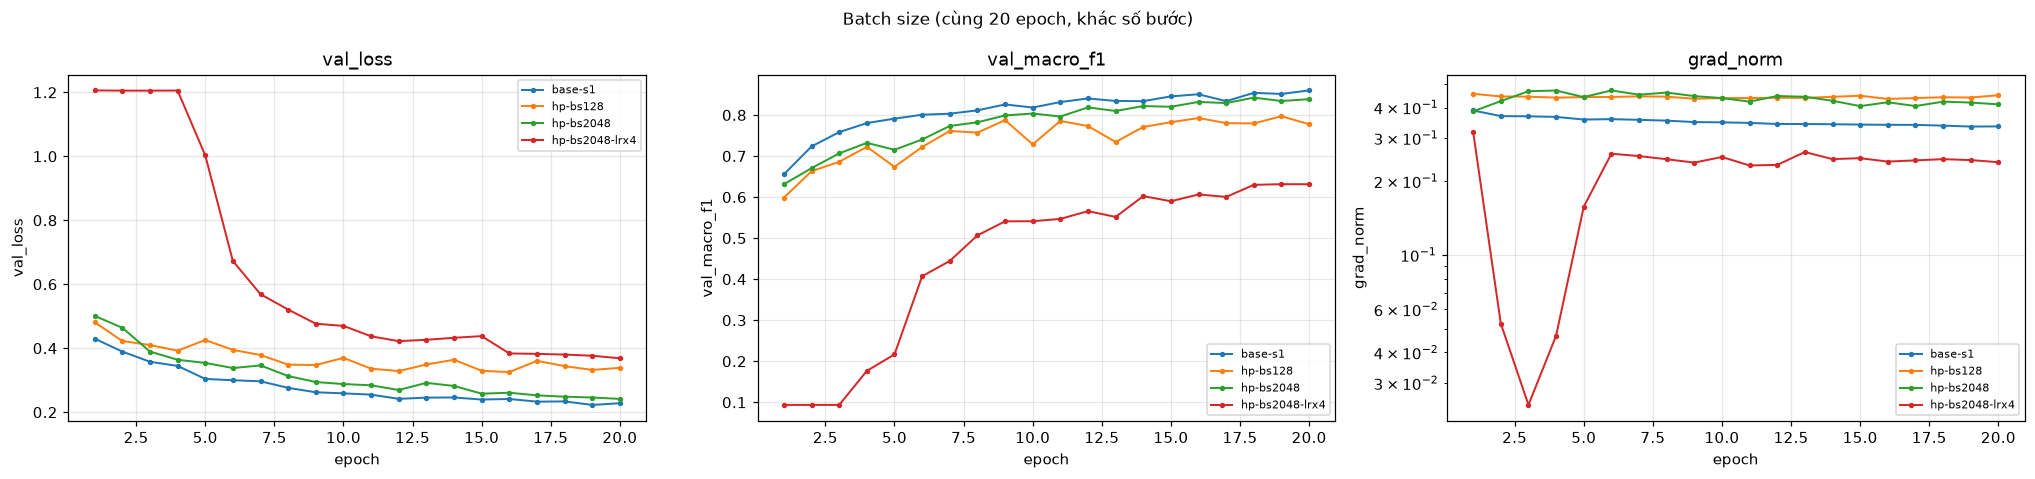

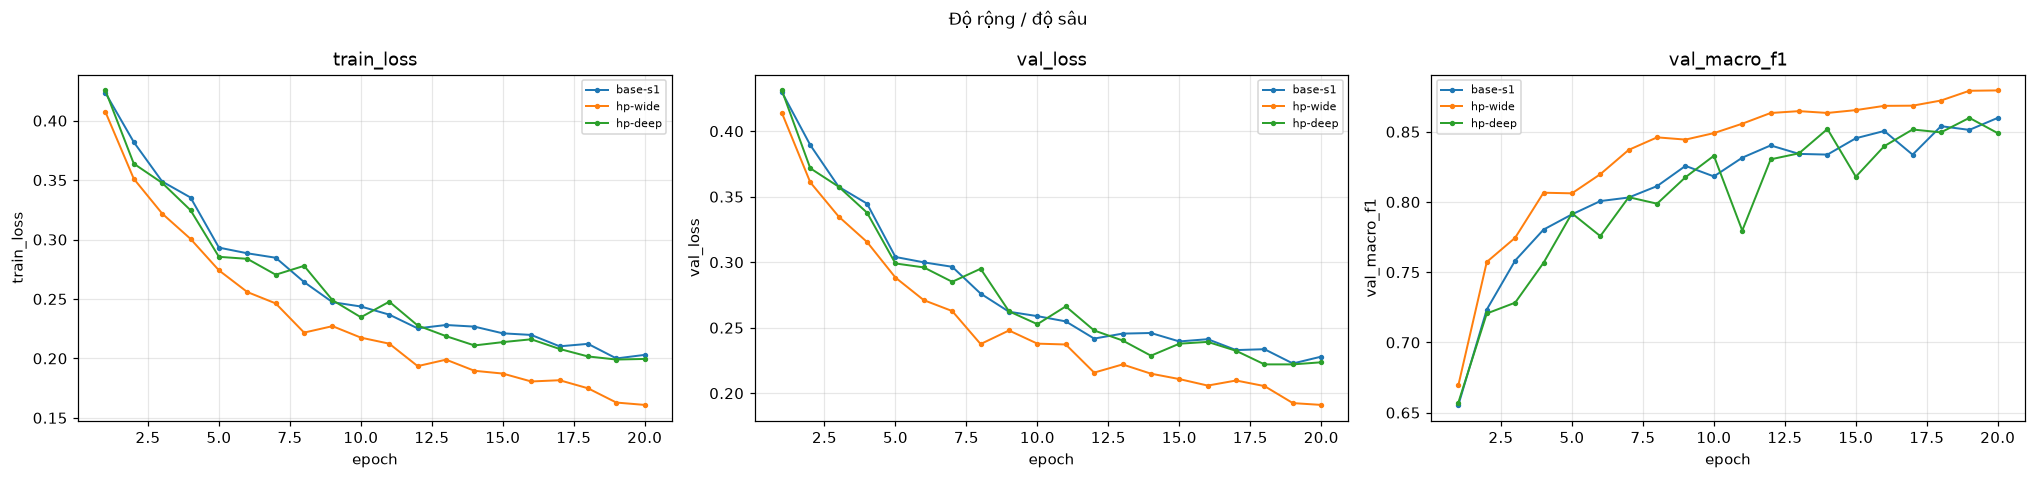

In [10]:
run({**BASE_CFG, "exp_id": "hp-bs128", "group": "hparam", "batch": 128, "description": "batch 128 (số bước x4)"}, notes="chỉ đổi batch; cùng epoch => số bước cập nhật x4")
run({**BASE_CFG, "exp_id": "hp-bs2048", "group": "hparam", "batch": 2048, "description": "batch 2048 (số bước /4)"}, notes="chỉ đổi batch; cùng epoch => số bước cập nhật /4")
run({**BASE_CFG, "exp_id": "hp-bs2048-lrx4", "group": "hparam", "batch": 2048, "lr": 4 * BASE_LR, "description": "batch 2048, lr x4 (quy tắc tăng lr theo lô)"},
    notes="đổi HAI yếu tố: batch x4 và lr x4; không có khởi động (warm-up)")
run({**BASE_CFG, "exp_id": "hp-wide", "group": "hparam", "hidden": (512, 256), "description": "M-wide 54-512-256-7 (161 287 tham số)"}, notes="chỉ đổi kiến trúc: M-wide")
run({**BASE_CFG, "exp_id": "hp-deep", "group": "hparam", "hidden": (256, 128, 64), "description": "M-deep 54-256-128-64-7 (55 687 tham số)"}, notes="chỉ đổi kiến trúc: M-deep")
HP_IDS = ["base-s1", "hp-bs128", "hp-bs2048", "hp-bs2048-lrx4", "hp-wide", "hp-deep"]
display(table(HP_IDS))
plot_compare([RES[e] for e in ["base-s1", "hp-bs128", "hp-bs2048", "hp-bs2048-lrx4"]], ["val_loss", "val_macro_f1", "grad_norm"],
             f"{OUT_DIR}/figures/compare_hparam_batch.png", "Batch size (cùng 20 epoch, khác số bước)")
plot_compare([RES[e] for e in ["base-s1", "hp-wide", "hp-deep"]], ["train_loss", "val_loss", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_hparam_arch.png", "Độ rộng / độ sâu")
display(Image(f"{OUT_DIR}/figures/compare_hparam_batch.png")); display(Image(f"{OUT_DIR}/figures/compare_hparam_arch.png"))

**Đối chiếu sau khi chạy:** - **Batch 128: trái dự đoán.** `hp-bs128` chỉ đạt 0,7926, thấp hơn trung bình baseline 0,0637 (vượt 2σ), dù có 58 120 bước (gấp 4) và tốn 6,0 s/epoch so với ~1,0 s. Macro-F1 nhảy mạnh giữa các epoch (0,787 → 0,728 → 0,786). Tôi đã bỏ qua việc lr = 0,3 được dò cho lô 512: với lô nhỏ hơn 4 lần, gradient nhiễu hơn mà bước vẫn giữ nguyên, tương đương tăng tỉ lệ lr/batch lên 4 lần. Hình dạng này giống `hp-lr1` (lr gấp 3,3 lần ở lô 512: 0,7701, cũng dao động). Giả thuyết "lô 128 cần lr ≈ 0,075" chưa được kiểm chứng vì tôi không chạy cấu hình đó.
- **Batch 2048: đúng hướng.** `hp-bs2048` đạt 0,8386, thấp hơn baseline 0,0177 (vượt 2σ) với chỉ 3 640 bước, và nhanh nhất (0,36 s/epoch). Ít bước hơn 4 lần nhưng chỉ mất 0,018 macro-F1.
- **Quy tắc lr × 4: trái dự đoán.** `hp-bs2048-lrx4` (lr = 1,2) rơi xuống 0,6313: 3 epoch đầu mắc ở dự đoán lớp đa số (macro-F1 0,094), `grad_norm` lớn nhất ở epoch 1 là 15,1, rồi hồi phục chậm. Không có giai đoạn khởi động, lr 1,2 quá lớn ngay từ đầu (lr 1,0 ở lô 512 cũng đã hỏng). Quy tắc tăng lr theo lô trong slide đi kèm khởi động; thí nghiệm này cho thấy thiếu khởi động thì quy tắc không dùng được ở đây, còn có khởi động thì sao tôi chưa thử.
- **Kiến trúc:** `hp-wide` đạt 0,8794, hơn trung bình baseline 0,0231 (vượt 2σ), train loss cuối 0,161 so với 0,203: thêm năng lực giúp vì baseline đang chưa khớp. `hp-deep` đạt 0,8599 (+0,0036, **trong nhiễu**): thêm một lớp 64 nơ-ron không cho khác biệt đo được. Đúng dự đoán.

### Chủ đề 4 — Dropout: `drop-0.1`, `drop-0.3`, `drop-0.5`
**Dự đoán trước:** dropout là thuốc cho quá khớp. Trước khi chạy, ô dưới in khoảng cách val − train của baseline. Nếu khoảng cách đó nhỏ (mô hình chưa quá khớp) thì dropout chỉ làm giảm năng lực hiệu dụng: tôi dự đoán val macro-F1 giảm dần theo `p`, `p = 0,5` tệ nhất; khoảng cách train–val thu hẹp (thậm chí val loss < train loss không xảy ra vì cả hai đều đo ở `eval()`), và train loss đo ở `eval()` cao hơn baseline.

baseline base-s1: train loss cuối 0.2030, val loss cuối 0.2279 -> khoảng cách val − train = +0.0250  (best epoch 19/20)


drop-0.1           best_ep 20  val_loss 0.2440  train_loss(cuối) 0.2291  acc 0.8996  f1 0.8405  gn_p50 0.289  1.66s/ep  (tổng 36s)


drop-0.3           best_ep 19  val_loss 0.3201  train_loss(cuối) 0.3145  acc 0.8681  f1 0.7637  gn_p50 0.281  1.63s/ep  (tổng 35s)


drop-0.5           best_ep 18  val_loss 0.4214  train_loss(cuối) 0.4196  acc 0.8227  f1 0.6693  gn_p50 0.290  1.63s/ep  (tổng 35s)


,opt,lr,batch,epochs,best_ep,step0,train_loss,val_loss,val_acc,val_f1,s_per_ep,mem_MB,steps,diverged,d_f1_vs_base,vượt_2σ,gap_val_minus_train
exp_id,,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.3,512,20,19,2.2691,0.2030,0.2227,0.9093,0.8513,1.0359,165.8730,14540,False,-0.0050,False,0.0250
drop-0.1,sgd_momentum,0.3,512,20,20,2.2691,0.2291,0.2440,0.8996,0.8405,1.6566,169.6313,14540,False,-0.0158,True,0.0149
drop-0.3,sgd_momentum,0.3,512,20,19,2.2691,0.3145,0.3201,0.8681,0.7637,1.6319,169.8145,14540,False,-0.0926,True,0.0065
drop-0.5,sgd_momentum,0.3,512,20,18,2.2691,0.4196,0.4214,0.8227,0.6693,1.6284,169.9976,14540,False,-0.1870,True,0.0041


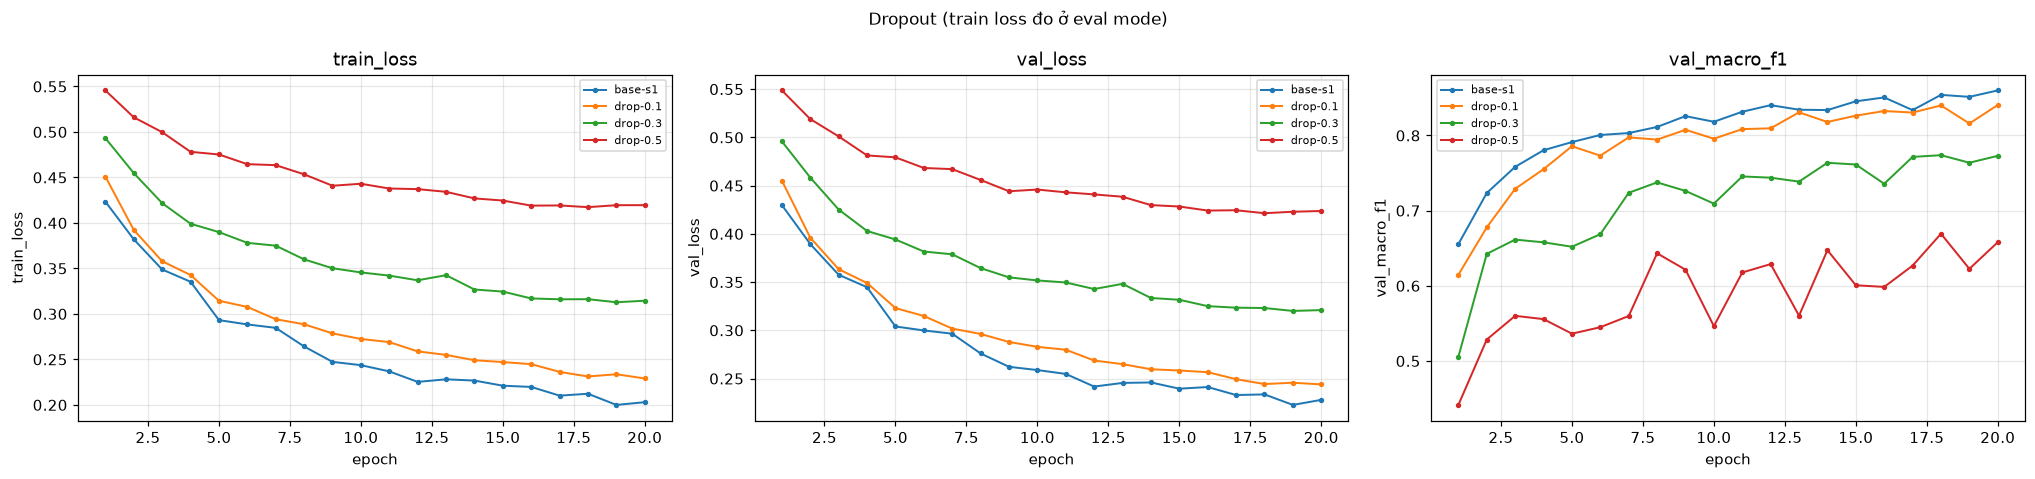

In [11]:
b = RES["base-s1"]["summary"]
print(f"baseline base-s1: train loss cuối {b['final_train_loss']:.4f}, val loss cuối {b['final_val_loss']:.4f} "
      f"-> khoảng cách val − train = {b['final_val_loss'] - b['final_train_loss']:+.4f}  (best epoch {b['best_epoch']}/20)")
for p in (0.1, 0.3, 0.5):
    run({**BASE_CFG, "exp_id": f"drop-{p:g}", "group": "dropout", "dropout": p, "description": f"dropout p={p:g} sau ReLU lớp ẩn"}, notes="chỉ đổi dropout; train loss đo ở eval()")
DROP_IDS = ["base-s1", "drop-0.1", "drop-0.3", "drop-0.5"]
t = table(DROP_IDS); t["gap_val_minus_train"] = [RES[e]["summary"]["final_val_loss"] - RES[e]["summary"]["final_train_loss"] for e in DROP_IDS]
display(t.round(4))
plot_compare([RES[e] for e in DROP_IDS], ["train_loss", "val_loss", "val_macro_f1"], f"{OUT_DIR}/figures/compare_dropout.png", "Dropout (train loss đo ở eval mode)")
display(Image(f"{OUT_DIR}/figures/compare_dropout.png"))

**Đối chiếu sau khi chạy:** khớp dự đoán. Baseline có khoảng cách val − train chỉ +0,025 và best epoch 19/20, tức chưa quá khớp. Dropout làm val macro-F1 giảm đơn điệu: `drop-0.1` 0,8405 (−0,0158 so với trung bình baseline), `drop-0.3` 0,7637 (−0,0926), `drop-0.5` 0,6693 (−0,1870); cả ba vượt 2σ = 0,0095. Khoảng cách train–val đúng là thu hẹp (0,0250 → 0,0149 → 0,0065 → 0,0041), nhưng vì **train loss tăng** (0,203 → 0,229 → 0,315 → 0,420, đo ở `eval()` nên không phải do nơ-ron còn bị tắt lúc đo), không phải vì val loss giảm. Cơ chế: tắt ngẫu nhiên nơ-ron làm giảm năng lực hiệu dụng và thêm nhiễu vào gradient của một mạng vốn đã chưa khớp sau 20 epoch. Dropout chỉ đáng thử khi train loss thấp hơn val loss rõ rệt; cấu hình cuối (40 epoch, mạng rộng) có khoảng cách 0,055 và là nơi đáng thử hơn, nhưng tôi chưa chạy. 1 seed mỗi giá trị.

### Chủ đề 5 — Gradient clipping: `clip-base`, `clip-hi-noclip`, `clip-hi-clip`
Ngưỡng `c` được chọn từ `grad_norm` đo ở baseline: `c` = trung vị chuẩn gradient mỗi bước của `base-s1` (làm tròn 2 chữ số có nghĩa), để clipping kích hoạt ở khoảng một nửa số bước thay vì không bao giờ.

**Dự đoán trước:**
- `clip-base` (lr baseline, clip `c`): clipping kích hoạt ~50% số bước, tương đương giảm bước ở các lô có gradient lớn; huấn luyện vẫn ổn định, kết quả gần baseline hoặc hơi thấp hơn (cắt cả những bước lẽ ra có ích). Chênh lệch có thể nằm trong nhiễu.
- Phản chứng ở lr cao (lr = 10 × lr baseline): `clip-hi-noclip` sẽ dao động mạnh hoặc phân kỳ (gai `grad_norm`, loss tăng vọt, có thể NaN); `clip-hi-clip` với cùng `c` giới hạn độ dài mỗi bước ở `lr·c` nên phải huấn luyện được và tốt hơn hẳn bản không clip. Đây mới là tình huống clipping sinh ra để xử lý.

grad_norm mỗi bước của base-s1: p50 = 0.3448, p90 = 0.4051, max = 3.0120
chọn c = 0.34 (≈ trung vị);  lr cao cho thí nghiệm phản chứng = 3


clip-base          best_ep 19  val_loss 0.2223  train_loss(cuối) 0.2065  acc 0.9110  f1 0.8599  gn_p50 0.370  1.34s/ep  (tổng 29s)


clip-hi-noclip     best_ep 19  val_loss 1.2058  train_loss(cuối) 1.2245  acc 0.4876  f1 0.0936  gn_p50 0.070  1.40s/ep  (tổng 30s)


clip-hi-clip       best_ep  3  val_loss 0.9317  train_loss(cuối) 0.9827  acc 0.5241  f1 0.1925  gn_p50 0.134  1.34s/ep  (tổng 29s)


,opt,lr,batch,epochs,best_ep,step0,train_loss,val_loss,val_acc,val_f1,s_per_ep,mem_MB,steps,diverged,d_f1_vs_base,vượt_2σ,grad_norm_p50,grad_norm_p90,grad_norm_max,clip_fraction,epochs_done
exp_id,,,,,,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.3,512,20,19,2.2691,0.2030,0.2227,0.9093,0.8513,1.0359,165.8730,14540,False,-0.0050,False,0.3448,0.4051,3.0120,NaN,20
clip-base,sgd_momentum,0.3,512,20,19,2.2691,0.2065,0.2223,0.9110,0.8599,1.3427,170.1807,14540,False,0.0036,False,0.3701,0.4418,2.8264,0.7653,20
clip-hi-noclip,sgd_momentum,3.0,512,20,19,2.2691,1.2245,1.2058,0.4876,0.0936,1.3970,170.3638,14540,False,-0.7626,True,0.0697,0.1549,294.2611,NaN,20
clip-hi-clip,sgd_momentum,3.0,512,20,3,2.2691,0.9827,0.9317,0.5241,0.1925,1.3406,170.5469,14540,False,-0.6638,True,0.1343,0.2518,4.1822,0.0393,20


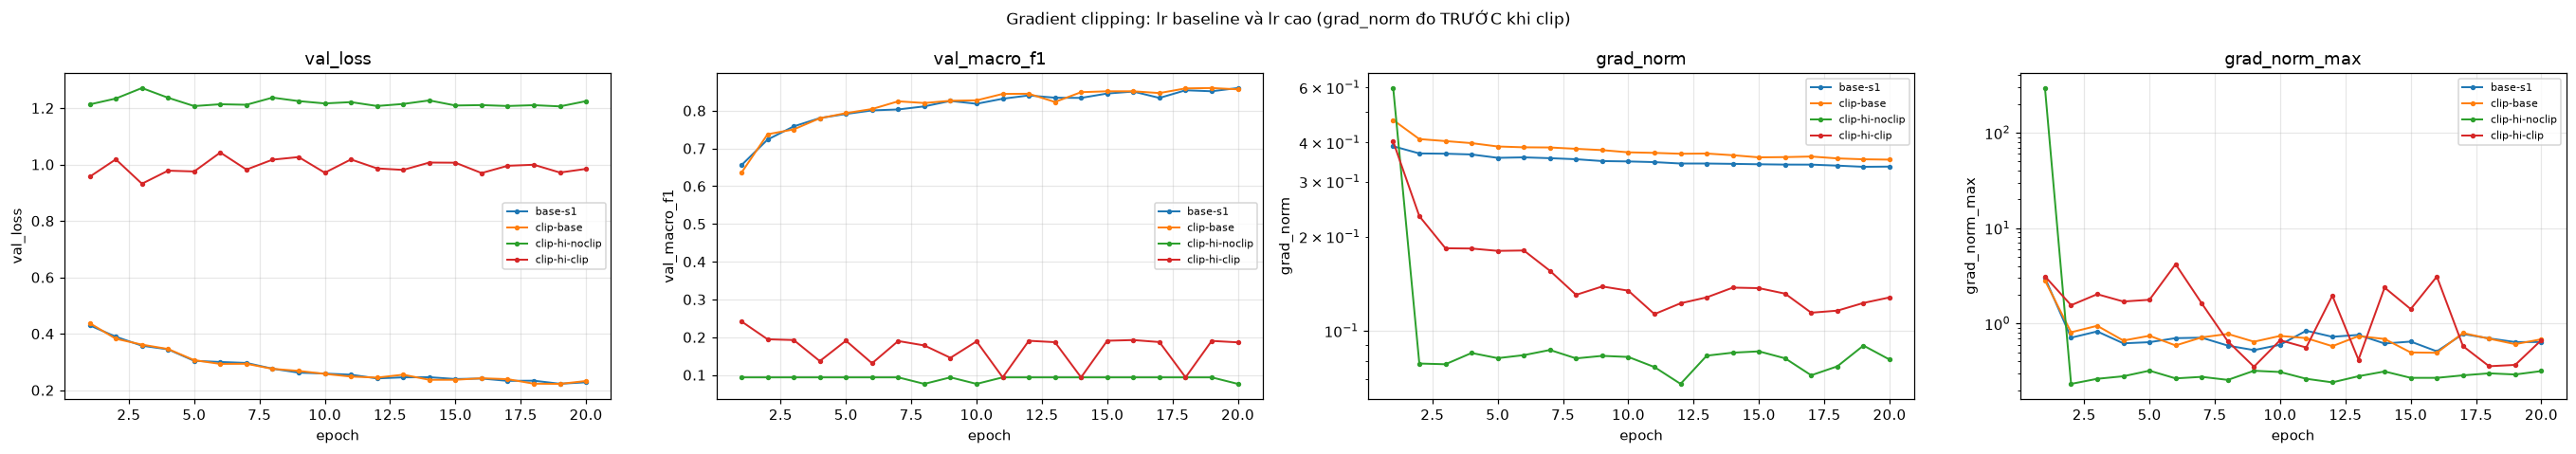

In [12]:
gs = RES["base-s1"]["summary"]
print(f"grad_norm mỗi bước của base-s1: p50 = {gs['grad_norm_p50']:.4f}, p90 = {gs['grad_norm_p90']:.4f}, max = {gs['grad_norm_max']:.4f}")
CLIP_C = float(f"{gs['grad_norm_p50']:.2g}")
HIGH_LR = 10 * BASE_LR
print(f"chọn c = {CLIP_C} (≈ trung vị);  lr cao cho thí nghiệm phản chứng = {HIGH_LR:g}")
run({**BASE_CFG, "exp_id": "clip-base", "group": "clipping", "clip_norm": CLIP_C, "description": f"clip c={CLIP_C:g} ở lr baseline"}, notes="chỉ đổi clip_norm; c = trung vị grad_norm của base-s1")
run({**BASE_CFG, "exp_id": "clip-hi-noclip", "group": "clipping", "lr": HIGH_LR, "description": f"lr cao {HIGH_LR:g}, không clip"}, notes="đối chứng của clip-hi-clip: chỉ đổi lr (x10) so với baseline")
run({**BASE_CFG, "exp_id": "clip-hi-clip", "group": "clipping", "lr": HIGH_LR, "clip_norm": CLIP_C, "description": f"lr cao {HIGH_LR:g}, clip c={CLIP_C:g}"}, notes="so với clip-hi-noclip: chỉ thêm clip")
CLIP_IDS = ["base-s1", "clip-base", "clip-hi-noclip", "clip-hi-clip"]
t = table(CLIP_IDS)
for k in ("grad_norm_p50", "grad_norm_p90", "grad_norm_max", "clip_fraction", "epochs_done"):
    t[k] = [RES[e]["summary"].get(k) for e in CLIP_IDS]
display(t.round(4))
plot_compare([RES[e] for e in CLIP_IDS], ["val_loss", "val_macro_f1", "grad_norm", "grad_norm_max"], f"{OUT_DIR}/figures/compare_clipping.png",
             "Gradient clipping: lr baseline và lr cao (grad_norm đo TRƯỚC khi clip)")
display(Image(f"{OUT_DIR}/figures/compare_clipping.png"))

**Đối chiếu sau khi chạy:** - **Ở lr baseline** (`clip-base`, c = 0,34): clipping kích hoạt ở **76,5%** số bước (nhiều hơn 50% dự kiến vì khi bước bị cắt ngắn, mô hình ở lại vùng gradient lớn lâu hơn: trung vị `grad_norm` tăng từ 0,345 lên 0,370). Val macro-F1 0,8599, hơn trung bình baseline 0,0036: **trong nhiễu**, đúng dự đoán. Baseline không có gai gradient sau epoch 1 (giá trị lớn nhất mỗi epoch quanh 0,6–0,8), nên không có gì để clipping sửa.
- **Ở lr cao (lr = 3,0): dự đoán chỉ đúng một phần.** `clip-hi-noclip` không ra NaN (cờ `diverged` = Không) nhưng sụp ngay epoch 1: `grad_norm` lớn nhất **294**, sau đó mô hình kẹt ở dự đoán lớp đa số (accuracy 0,4876, macro-F1 0,0936, val loss 1,206, đúng bằng mức của `init-zeros`) với gradient gần như tắt (trung vị 0,07). Tôi cho rằng vài bước khổng lồ đầu tiên đã đẩy phần lớn nơ-ron ReLU vào vùng chết; đây là phỏng đoán, tôi chưa đếm số nơ-ron chết. `clip-hi-clip` giới hạn được gai (lớn nhất 4,2 thay vì 294) và khá hơn: macro-F1 0,1925, accuracy 0,5241, nhưng **không cứu được** huấn luyện: tốt nhất ở epoch 3 rồi dao động quanh 0,09–0,19. Với c = 0,34 mỗi bước vẫn dài tới `lr·c ≈ 1,0` (cộng thêm momentum), quá lớn. Clipping chỉ kích hoạt ở 3,9% số bước vì sau giai đoạn đầu gradient đã nhỏ.
- Kết luận đo được: clipping chặn gai gradient (294 → 4,2) và làm kết quả bớt tệ, nhưng không thay thế được việc chọn lr đúng khi lr cao gấp 10 lần. Muốn thấy clipping "cứu" hẳn một lần chạy, cần lr cao vừa phải hơn (ví dụ 1,0) hoặc c nhỏ hơn; chưa thử.

### Chủ đề 6 — Mixed precision: `amp-fp16`, `amp-bf16`
**Dự đoán trước:** tham số vẫn FP32, autocast chỉ hạ độ chính xác của phép nhân ma trận. Với MLP 48k tham số và lô 512, mỗi bước là vài phép nhân ma trận rất nhỏ; thời gian bị chi phối bởi chi phí gọi kernel, Python và đồng bộ `.item()`, không phải bởi số học. Tôi dự đoán FP16/BF16 **không nhanh hơn**, thậm chí chậm hơn một chút (thêm ép kiểu và `GradScaler`), bộ nhớ đỉnh gần như không đổi (phần lớn là tensor dữ liệu nằm sẵn trên GPU), và metric trùng FP32 trong phạm vi nhiễu seed. Ô thứ hai đo thêm một mạng rất rộng để xem khi nào mixed precision bắt đầu có lợi.

amp-fp16           best_ep 20  val_loss 0.2205  train_loss(cuối) 0.1951  acc 0.9128  f1 0.8597  gn_p50 0.344  2.19s/ep  (tổng 47s)


amp-bf16           best_ep 20  val_loss 0.2182  train_loss(cuối) 0.1934  acc 0.9133  f1 0.8624  gn_p50 0.344  1.90s/ep  (tổng 41s)


,opt,lr,batch,epochs,best_ep,step0,train_loss,val_loss,val_acc,val_f1,s_per_ep,mem_MB,steps,diverged,d_f1_vs_base,vượt_2σ,skipped_steps
exp_id,,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.3,512,20,19,2.2691,0.2030,0.2227,0.9093,0.8513,1.0359,165.8730,14540,False,-0.0050,False,0
amp-fp16,sgd_momentum,0.3,512,20,20,2.2691,0.1951,0.2205,0.9128,0.8597,2.1872,170.7310,14540,False,0.0034,False,4
amp-bf16,sgd_momentum,0.3,512,20,20,2.2691,0.1934,0.2182,0.9133,0.8624,1.8986,170.9131,14540,False,0.0061,False,0


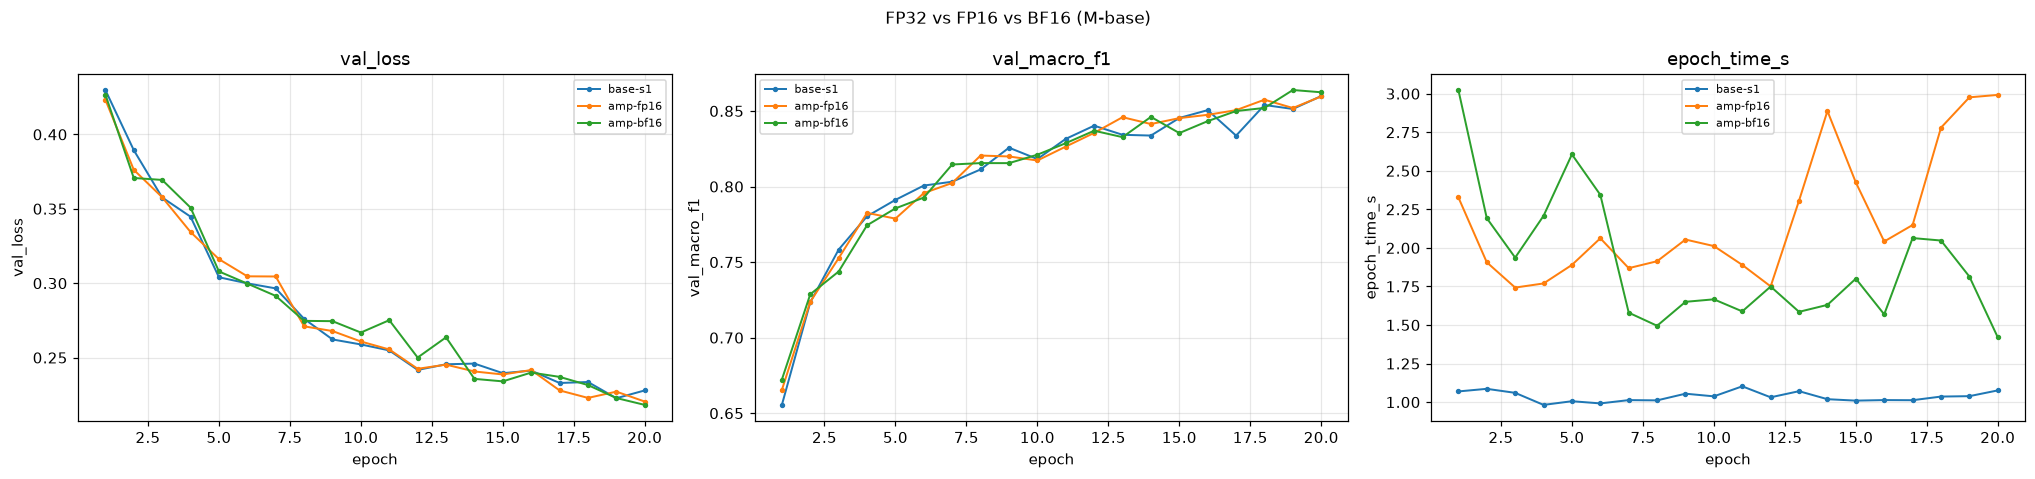

In [13]:
run({**BASE_CFG, "exp_id": "amp-fp16", "group": "amp", "precision": "fp16", "description": "autocast float16 + GradScaler"}, notes="chỉ đổi precision; unscale_ trước khi đo grad_norm")
run({**BASE_CFG, "exp_id": "amp-bf16", "group": "amp", "precision": "bf16", "description": "autocast bfloat16, không GradScaler"}, notes="chỉ đổi precision")
AMP_IDS = ["base-s1", "amp-fp16", "amp-bf16"]
t = table(AMP_IDS); t["skipped_steps"] = [RES[e]["summary"].get("skipped_steps") for e in AMP_IDS]
display(t)
ok = [RES[e] for e in AMP_IDS if RES[e]["history"]["epoch"]]
plot_compare(ok, ["val_loss", "val_macro_f1", "epoch_time_s"], f"{OUT_DIR}/figures/compare_amp.png", "FP32 vs FP16 vs BF16 (M-base)")
display(Image(f"{OUT_DIR}/figures/compare_amp.png"))

In [14]:
# Tuỳ chọn (không phải dòng của bảng): thời gian mỗi bước forward+backward theo độ rộng, FP32 vs FP16/BF16, lô 512.
def bench(width, precision, steps=100, batch=512):
    m = MLP(hidden=(width, width), init="he").to(device); o = torch.optim.SGD(m.parameters(), lr=1e-3)
    xb, yb = data["X_tr"][:batch], data["y_tr"][:batch]
    dt = {"fp16": torch.float16, "bf16": torch.bfloat16}.get(precision, torch.float32)
    sc = torch.amp.GradScaler("cuda") if precision == "fp16" else None
    for i in range(steps + 20):
        if i == 20:
            torch.cuda.synchronize(); t0 = time.perf_counter()        # 20 bước đầu để làm nóng
        with torch.autocast("cuda", dtype=dt, enabled=precision != "fp32"):
            loss = compute_loss(m(xb), yb, "ce")
        o.zero_grad(set_to_none=True)
        if sc: sc.scale(loss).backward(); sc.step(o); sc.update()
        else:  loss.backward(); o.step()
    torch.cuda.synchronize(); return 1000 * (time.perf_counter() - t0) / steps

if device == "cuda":
    rows = [dict(width=w, **{p: bench(w, p) for p in ("fp32", "fp16", "bf16")}) for w in (256, 1024, 4096, 8192)]
    bt = pd.DataFrame(rows).set_index("width"); bt["fp32/fp16"] = bt["fp32"] / bt["fp16"]; bt["fp32/bf16"] = bt["fp32"] / bt["bf16"]
    print("ms mỗi bước (forward + backward + cập nhật), mạng 54 → w → w → 7:"); display(bt.round(3))
else:
    print("không có CUDA: bỏ qua phép đo phụ này")

ms mỗi bước (forward + backward + cập nhật), mạng 54 → w → w → 7:


,fp32,fp16,bf16,fp32/fp16,fp32/bf16
width,,,,,
256,2.477,3.200,2.337,0.774,1.060
1024,1.725,1.782,1.685,0.968,1.024
4096,13.465,6.952,5.853,1.937,2.301
8192,50.866,24.945,21.361,2.039,2.381


**Đối chiếu sau khi chạy:** - **Độ chính xác:** `amp-fp16` 0,8597 và `amp-bf16` 0,8624, so với trung bình baseline 0,8563: chênh +0,0034 và +0,0061, **trong nhiễu** (2σ = 0,0095). Đúng dự đoán. FP16 có 4 bước bị `GradScaler` bỏ qua (gradient không hữu hạn sau `unscale_`) trên 14 540 bước; BF16 không có bước nào.
- **Thời gian: không kết luận được từ ba lần chạy này.** Số đo là 2,19 s/epoch (FP16) và 1,90 (BF16) so với 1,04 (`base-s1`), nhưng thời gian trên laptop này trôi theo thời điểm chạy: bốn lần `init-*` chạy ngay sau đó, cùng FP32 và cùng cấu hình, cũng mất 1,8–1,9 s/epoch, còn `hp-lr0.1` mất 1,59 s. Vì vậy tôi không quy mức chậm hơn cho mixed precision. Điều chắc chắn là **không có bằng chứng nhanh hơn**.
- **Phép đo phụ có kiểm soát** (100 bước liên tiếp, lô 512): ở độ rộng 256, FP16 chậm hơn FP32 (3,20 so với 2,48 ms/bước; BF16 2,34); ở 1024 gần như bằng nhau; ở 4096 FP16/BF16 nhanh gấp 1,9/2,3 lần và ở 8192 gấp 2,0/2,4 lần. Với `M-base`, mỗi bước chỉ là vài phép nhân ma trận nhỏ nên thời gian do chi phí gọi kernel, Python và `.item()` chi phối; số học nửa độ chính xác chỉ có lợi khi ma trận đủ lớn.
- **Bộ nhớ:** 170,7 và 170,9 MB so với 165,9 MB. Số này gồm cả tensor dữ liệu nằm sẵn trên GPU và tăng dần theo thứ tự chạy trong notebook (165 → 172 MB) do các `best_state` được giữ lại, nên không phản ánh khác biệt của precision.
- FP16 cần `GradScaler` vì số dương chuẩn hoá nhỏ nhất của FP16 cỡ 6·10⁻⁵, gradient nhỏ bị làm tròn về 0 nếu không nhân loss lên trước; BF16 giữ dải số mũ của FP32 (đổi lại ít bit trị số hơn) nên không cần.

### Chủ đề 7 — Khởi tạo tham số: `init-zeros`, `init-normal`, `init-xavier`, `init-default`
`he` là baseline. `xavier` ở đây là `nn.init.xavier_normal_`, tức `Var[W] = 2/(n_vào + n_ra)` (không phải `1/n_vào` của slide). `default` là mặc định của `nn.Linear` (`U(±1/√n_vào)`, `Var = 1/(3·n_vào)`, bias cũng ngẫu nhiên). Kích hoạt được đo **sau ReLU** ở lớp ẩn và trên **logit** ở lớp cuối, trên 8 192 mẫu val, ở bước 0.

**Dự đoán trước:**
- `zeros`: mọi `W = 0`, `b = 0` nên mọi kích hoạt bằng 0 và logit bằng 0 → loss bước 0 đúng bằng `ln 7`. Gradient của `W3` là `h2ᵀ·δ = 0` vì `h2 = 0`; gradient truyền về lớp trước nhân với `W3 = 0` (và đạo hàm ReLU tại 0 là 0) nên `W1, W2` cũng nhận gradient 0. Chỉ `b3` có gradient khác 0. Mạng chỉ học được 7 bias đầu ra, tức phân phối lớp: dự đoán luôn lớp đa số, accuracy ≈ 0,4876, macro-F1 ≈ 0,094, loss dừng ở entropy của phân phối lớp (≈ 1,2). Các nơ-ron cùng lớp hoàn toàn đối xứng và không có gì phá đối xứng.
- `normal` (std 0,01): kích hoạt co lại qua từng lớp, logit ≈ 0, loss bước 0 ≈ `ln 7`; gradient đầu rất nhỏ nên khởi động chậm, nhưng đối xứng đã bị phá và mạng chỉ có 3 lớp nên vẫn học được; kết quả cuối kém He một chút hoặc tương đương.
- `xavier`, `default`: phương sai nhỏ hơn He (không bù cho việc ReLU bỏ một nửa), logit nhỏ hơn nên loss bước 0 gần `ln 7` hơn He; với mạng 3 lớp tôi dự đoán kết quả cuối tương đương He trong phạm vi nhiễu.

,std_h1_sau_ReLU,std_h2_sau_ReLU,std_logit,loss_buoc0,‖g W1‖,‖g b1‖,‖g W2‖,‖g b2‖,‖g W3‖,‖g b3‖
init,,,,,,,,,,
zeros,0.00000,0.00000,0.00000,1.94591,0.00000,0.00000,0.00000,0.00000,0.00000,0.48804
normal,0.02019,0.00215,0.00027,1.94599,0.00380,0.00266,0.00690,0.02994,0.00966,0.48807
xavier,0.16219,0.12449,0.19131,2.02129,0.34639,0.24502,0.70801,0.38235,0.58510,0.50872
default,0.15923,0.06731,0.05804,1.98354,0.07434,0.05124,0.33704,0.18165,0.33147,0.49980
he,0.38861,0.36530,0.57654,2.26606,0.48711,0.34567,1.96276,0.43973,1.91973,0.56314


ln 7 = 1.9459


init-zeros         best_ep  6  val_loss 1.2053  train_loss(cuối) 1.2068  acc 0.4876  f1 0.0936  gn_p50 0.034  1.81s/ep  (tổng 39s)


init-normal        best_ep 19  val_loss 0.2238  train_loss(cuối) 0.2034  acc 0.9111  f1 0.8568  gn_p50 0.351  1.91s/ep  (tổng 41s)


init-xavier        best_ep 19  val_loss 0.2070  train_loss(cuối) 0.1876  acc 0.9165  f1 0.8590  gn_p50 0.346  1.93s/ep  (tổng 42s)


init-default       best_ep 19  val_loss 0.2176  train_loss(cuối) 0.1898  acc 0.9130  f1 0.8636  gn_p50 0.346  1.92s/ep  (tổng 42s)


,opt,lr,batch,epochs,best_ep,step0,train_loss,val_loss,val_acc,val_f1,s_per_ep,mem_MB,steps,diverged,d_f1_vs_base,vượt_2σ
exp_id,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.3,512,20,19,2.2691,0.2030,0.2227,0.9093,0.8513,1.0359,165.8730,14540,False,-0.0050,False
init-zeros,sgd_momentum,0.3,512,20,6,1.9459,1.2068,1.2053,0.4876,0.0936,1.8072,171.4624,14540,False,-0.7626,True
init-normal,sgd_momentum,0.3,512,20,19,1.9460,0.2034,0.2238,0.9111,0.8568,1.9051,171.6455,14540,False,0.0005,False
init-xavier,sgd_momentum,0.3,512,20,19,2.0222,0.1876,0.2070,0.9165,0.8590,1.9281,171.8286,14540,False,0.0027,False
init-default,sgd_momentum,0.3,512,20,19,1.9830,0.1898,0.2176,0.9130,0.8636,1.9248,172.0117,14540,False,0.0073,False


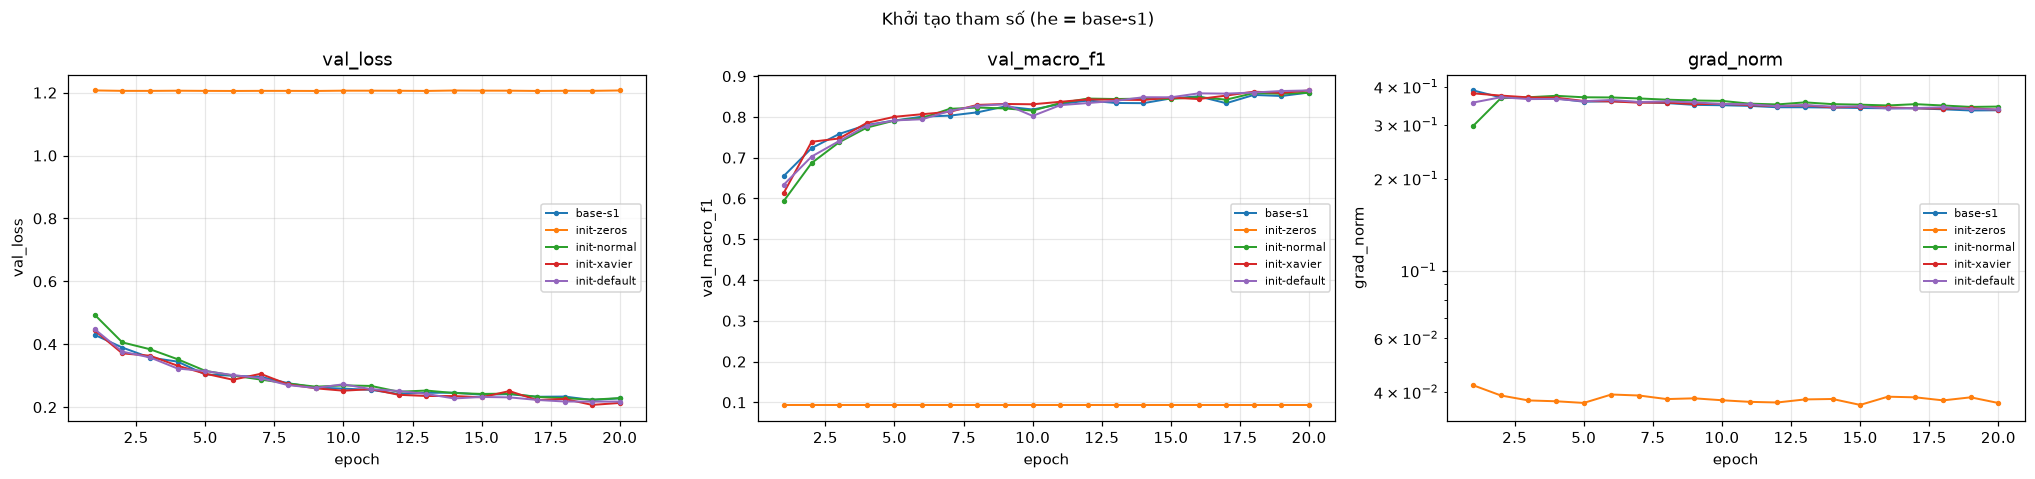

In [15]:
xv, yv = data["X_val"][:8192], data["y_val"][:8192]
rows = []
for init in ("zeros", "normal", "xavier", "default", "he"):
    set_seed(1); m = MLP(hidden=(256, 128), init=init).to(device)
    st = activation_stats(m, xv)
    loss = compute_loss(m(xv), yv, "ce"); loss.backward()
    g = {n: p.grad.norm().item() for n, p in zip(["W1", "b1", "W2", "b2", "W3", "b3"], m.parameters())}
    rows.append(dict(init=init, std_h1_sau_ReLU=st[0], std_h2_sau_ReLU=st[1], std_logit=st[2], loss_buoc0=loss.item(), **{f"‖g {k}‖": v for k, v in g.items()}))
display(pd.DataFrame(rows).set_index("init").round(5))
print("ln 7 =", round(math.log(7), 4))
for init in ("zeros", "normal", "xavier", "default"):
    run({**BASE_CFG, "exp_id": f"init-{init}", "group": "init", "init": init, "description": f"khởi tạo {init}"},
        notes={"zeros": "W=0, b=0", "normal": "W~N(0,0.01^2), b=0", "xavier": "xavier_normal_: Var=2/(n_in+n_out), b=0",
               "default": "mặc định nn.Linear: U(±1/sqrt(n_in)) cho cả W và b"}[init])
INIT_IDS = ["base-s1", "init-zeros", "init-normal", "init-xavier", "init-default"]
display(table(INIT_IDS))
plot_compare([RES[e] for e in INIT_IDS], ["val_loss", "val_macro_f1", "grad_norm"], f"{OUT_DIR}/figures/compare_init.png", "Khởi tạo tham số (he = base-s1)")
display(Image(f"{OUT_DIR}/figures/compare_init.png"))

**Đối chiếu sau khi chạy:** - **`zeros`: khớp dự đoán.** Mọi kích hoạt và logit bằng 0, loss bước 0 = 1,94591 = `ln 7`; chỉ `b3` có gradient (0,488), năm tham số còn lại gradient đúng bằng 0. Sau 20 epoch `init-zeros` vẫn ở accuracy 0,4876, macro-F1 0,0936, val loss 1,205: mạng chỉ học được 7 bias đầu ra, tức phân phối lớp. Gradient của `W3` là `h2ᵀδ` với `h2 = 0`; gradient truyền về trước bị nhân với `W3 = 0`. Không có gì phá đối xứng.
- **`normal` (std 0,01): tốt hơn dự đoán.** Kích hoạt co đúng như nghĩ (0,020 → 0,0022 → logit 0,0003; loss bước 0 = 1,9460), gradient ban đầu của `W1` chỉ 0,004. Nhưng `init-normal` đạt 0,8568, trùng trung bình baseline (+0,0005). Epoch 1 chậm hơn He (macro-F1 0,594 so với 0,656) rồi bắt kịp: với 3 lớp, tín hiệu chỉ co qua hai lần nhân và momentum với lr 0,3 kéo trọng số ra khỏi vùng nhỏ trong vài trăm bước.
- **`xavier`, `default`: khớp dự đoán.** Độ lệch chuẩn kích hoạt nhỏ hơn He (0,16/0,12 và 0,16/0,07 so với 0,39/0,37), loss bước 0 gần `ln 7` hơn (2,022 và 1,984 so với 2,266). Kết quả cuối `init-xavier` 0,8590 (+0,0027), `init-default` 0,8636 (+0,0073): **đều trong nhiễu**.
- Mạng 3 lớp **không đủ sâu** để thấy khác biệt giữa He, Xavier và mặc định như biểu đồ 30 lớp trong slide: He giữ độ lệch chuẩn gần như không đổi qua hai lớp ẩn (0,389 → 0,365), Xavier giảm ~23% mỗi lớp, một mức co chỉ thành vấn đề khi nhân qua hàng chục lớp. Khác biệt duy nhất vượt nhiễu là `zeros`.

### Kết hợp và chọn cấu hình cuối cùng (chỉ bằng val)
Quy tắc chọn được viết ra **trước khi chạy** và chỉ dùng số liệu val:
1. Bộ tối ưu và lr: cặp có val macro-F1 cao nhất trong toàn bộ lưới của Chủ đề 2.
2. Kiến trúc: tốt nhất theo val macro-F1 trong `M-base` (`base-s1`), `M-wide` (`hp-wide`), `M-deep` (`hp-deep`).
3. Số epoch 40 và lịch lr cosine (1 epoch khởi động): mọi lần chạy 20 epoch ở trên đều có best epoch ở sát cuối, tức chưa hội tụ; cosine giảm lr dần để giai đoạn cuối bớt dao động.
4. Dropout, clipping, mixed precision, MSE, khởi tạo khác He: **không** đưa vào, trừ khi thí nghiệm tương ứng vượt baseline quá 2σ trên val (ô dưới in ra để kiểm tra).

**Dự đoán trước:** cấu hình kết hợp vượt baseline trên val macro-F1 nhiều hơn 2σ, phần lớn nhờ huấn luyện dài hơn và mạng rộng hơn. Cấu hình này đổi nhiều yếu tố cùng lúc so với baseline (ghi trong `notes`), nên không tách được đóng góp của từng yếu tố. lr được dò trên `M-base`/20 epoch rồi dùng lại, chưa dò lại cho kiến trúc mới: đây là một hạn chế. Chạy 3 seed; nếu trung bình val macro-F1 không cao hơn baseline thì giữ baseline làm cấu hình cuối.

bộ tối ưu/lr tốt nhất theo val: opt-adam-lr0.003 (adam, lr=0.003, wd=0), val f1 0.8835
kiến trúc tốt nhất theo val   : hp-wide (512, 256), val f1 0.8794
thí nghiệm kỹ thuật khác vượt baseline > 2σ trên val: không có -> không đưa vào cấu hình cuối


final-s1           best_ep 39  val_loss 0.1213  train_loss(cuối) 0.0663  acc 0.9548  f1 0.9304  gn_p50 0.507  2.21s/ep  (tổng 97s)


final-s2           best_ep 40  val_loss 0.1203  train_loss(cuối) 0.0671  acc 0.9548  f1 0.9296  gn_p50 0.514  1.86s/ep  (tổng 79s)


final-s3           best_ep 40  val_loss 0.1209  train_loss(cuối) 0.0656  acc 0.9547  f1 0.9309  gn_p50 0.493  1.79s/ep  (tổng 76s)


,opt,lr,batch,epochs,best_ep,step0,train_loss,val_loss,val_acc,val_f1,s_per_ep,mem_MB,steps,diverged,d_f1_vs_base,vượt_2σ
exp_id,,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.300,512,20,19,2.2691,0.2030,0.2227,0.9093,0.8513,1.0359,165.8730,14540,False,-0.0050,False
base-s2,sgd_momentum,0.300,512,20,20,1.9782,0.1972,0.2236,0.9119,0.8609,1.0506,166.0562,14540,False,0.0046,False
base-s3,sgd_momentum,0.300,512,20,19,1.9005,0.1997,0.2174,0.9129,0.8567,1.0550,166.2393,14540,False,0.0004,False
final-s1,adam,0.003,512,40,39,1.9182,0.0663,0.1213,0.9548,0.9304,2.2080,190.5410,29080,False,0.0741,True
final-s2,adam,0.003,512,40,40,2.6520,0.0671,0.1203,0.9548,0.9296,1.8585,191.1567,29080,False,0.0733,True
final-s3,adam,0.003,512,40,40,2.7882,0.0656,0.1209,0.9547,0.9309,1.7853,191.7725,29080,False,0.0746,True


cấu hình kết hợp: val macro-F1 = 0.9303 ± 0.0007   | baseline: 0.8563 ± 0.0048
chênh lệch trung bình = +0.0740   (2σ baseline = 0.0095, 2σ cấu hình kết hợp = 0.0013)
=> cấu hình cuối cùng: cấu hình kết hợp | mô hình nộp: final-s1 (seed 1, epoch có val loss thấp nhất = 39)


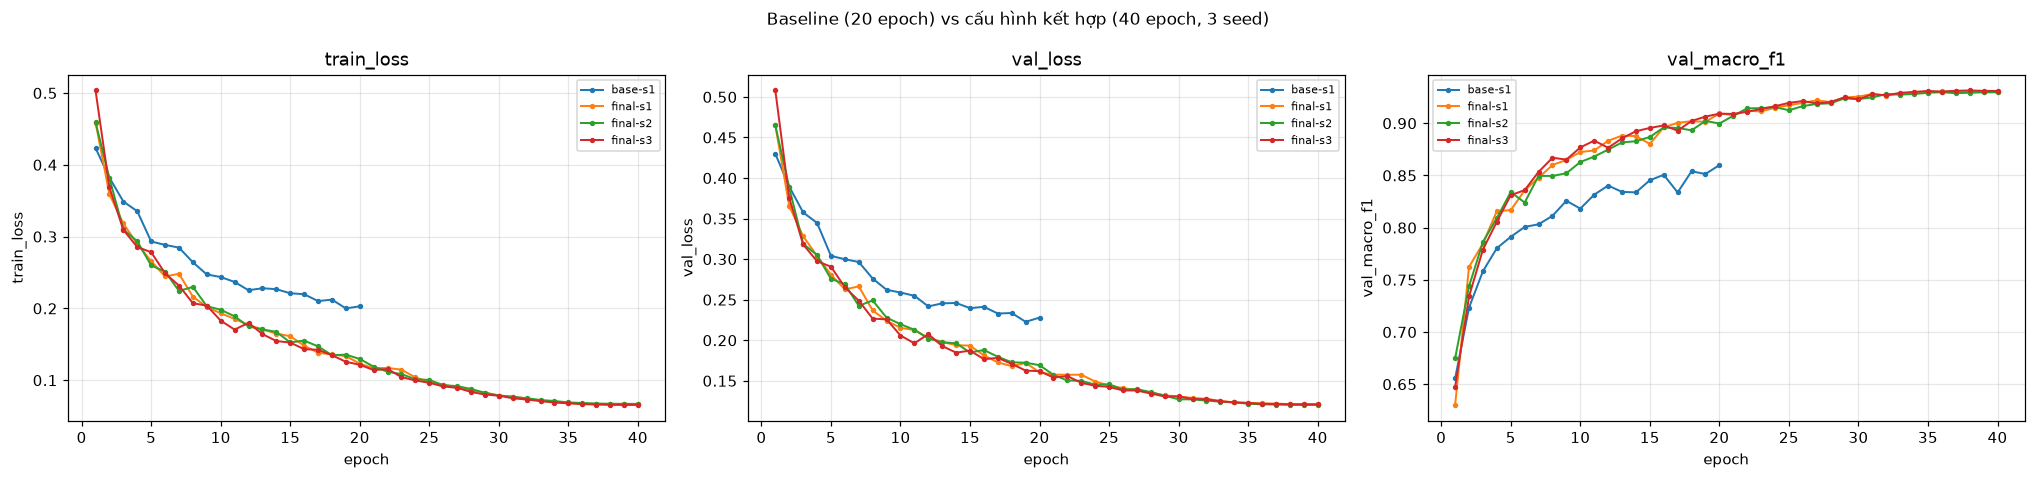

In [16]:
best_opt_id = max([e for ids in OPT_IDS.values() for e in ids], key=f1_of)
ARCH_IDS = {"base-s1": (256, 128), "hp-wide": (512, 256), "hp-deep": (256, 128, 64)}
best_arch_id = max(ARCH_IDS, key=f1_of)
oc = RES[best_opt_id]["cfg"]
print(f"bộ tối ưu/lr tốt nhất theo val: {best_opt_id} ({oc['optimizer']}, lr={oc['lr']:g}, wd={oc['weight_decay']:g}), val f1 {f1_of(best_opt_id):.4f}")
print(f"kiến trúc tốt nhất theo val   : {best_arch_id} {ARCH_IDS[best_arch_id]}, val f1 {f1_of(best_arch_id):.4f}")
others = ["loss-mse", "drop-0.1", "drop-0.3", "drop-0.5", "clip-base", "amp-fp16", "amp-bf16", "init-zeros", "init-normal", "init-xavier", "init-default"]
helped = [e for e in others if f1_of(e) - BASE_F1_MEAN > NOISE_2S]
print("thí nghiệm kỹ thuật khác vượt baseline > 2σ trên val:", helped if helped else "không có -> không đưa vào cấu hình cuối")

FINAL_CFG = {**BASE_CFG, "group": "final", "optimizer": oc["optimizer"], "lr": oc["lr"], "weight_decay": oc["weight_decay"],
             "hidden": ARCH_IDS[best_arch_id], "epochs": 40, "scheduler": "cosine"}
for s in (1, 2, 3):
    run({**FINAL_CFG, "exp_id": f"final-s{s}", "seed": s, "description": f"Cấu hình kết hợp, seed {s}"},
        notes=f"đổi NHIỀU yếu tố so với baseline: optimizer/lr từ {best_opt_id}, kiến trúc từ {best_arch_id}, 40 epoch, lr cosine")
FINAL_IDS = ["final-s1", "final-s2", "final-s3"]
display(table(BASE_IDS + FINAL_IDS))
ff = np.array([f1_of(e) for e in FINAL_IDS])
print(f"cấu hình kết hợp: val macro-F1 = {ff.mean():.4f} ± {ff.std(ddof=1):.4f}   | baseline: {BASE_F1_MEAN:.4f} ± {BASE_F1_STD:.4f}")
print(f"chênh lệch trung bình = {ff.mean() - BASE_F1_MEAN:+.4f}   (2σ baseline = {NOISE_2S:.4f}, 2σ cấu hình kết hợp = {2 * ff.std(ddof=1):.4f})")
USE_FINAL = ff.mean() > BASE_F1_MEAN
SUBMIT_ID = "final-s1" if USE_FINAL else "base-s1"          # seed nộp cố định là 1, không chọn seed theo điểm
print("=> cấu hình cuối cùng:", "cấu hình kết hợp" if USE_FINAL else "giữ baseline", "| mô hình nộp:", SUBMIT_ID,
      f"(seed 1, epoch có val loss thấp nhất = {RES[SUBMIT_ID]['summary']['best_epoch']})")
plot_compare([RES[e] for e in ["base-s1"] + FINAL_IDS], ["train_loss", "val_loss", "val_macro_f1"], f"{OUT_DIR}/figures/compare_final.png",
             "Baseline (20 epoch) vs cấu hình kết hợp (40 epoch, 3 seed)")
display(Image(f"{OUT_DIR}/figures/compare_final.png"))

**Đối chiếu sau khi chạy:** Quy tắc chọn cho ra: Adam, lr 3e-3, weight decay 0 (từ `opt-adam-lr0.003`, val macro-F1 0,8835) + `M-wide` (từ `hp-wide`, 0,8794) + 40 epoch + cosine. Không kỹ thuật nào khác vượt baseline quá 2σ trên val nên không đưa thêm gì.
- `final-s1/2/3`: val macro-F1 **0,9303 ± 0,0007** (0,9304; 0,9296; 0,9309), accuracy 0,9548. Hơn trung bình baseline **+0,0740**, gấp ~8 lần ngưỡng 2σ = 0,0095 của baseline: khác biệt vượt nhiễu, đúng dự đoán.
- Đường cong: val loss giảm tới epoch 39–40 (best epoch 39, 40, 40) và phẳng dần khi lr cosine về 0. Train loss cuối 0,066 so với val loss 0,121: khoảng cách 0,055, lớn hơn baseline (0,025). Mô hình đã bắt đầu khớp train nhanh hơn val nhưng val vẫn chưa xấu đi, nên chưa cần dừng sớm hơn.
- **Không tách được đóng góp** của từng yếu tố (Adam, mạng rộng, 40 epoch, cosine) vì chúng đổi cùng lúc; riêng lẻ ở 20 epoch thì Adam cho +0,027 và mạng rộng +0,023 so với trung bình baseline. lr 3e-3 được dò trên `M-base`/20 epoch và nằm ở mép lưới, chưa dò lại cho cấu hình này.
- **Chốt:** cấu hình cuối cùng = cấu hình kết hợp; mô hình nộp = `final-s1` (seed 1, trọng số tại epoch 39, epoch có val loss thấp nhất). Quyết định này có trước khi chạy ô đánh giá eval bên dưới.

## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài
Cấu hình và epoch đã chốt ở trên bằng val. Từ đây `X_eval` mới được dùng, đúng hai lần: `base-s1` (baseline) và mô hình nộp. Số eval chỉ lấy từ `scripts/evaluate.py`.

In [17]:
def official_eval(exp_id, pred_path, out_path):
    """Nạp best_state của exp_id -> dự đoán toàn bộ eval -> chấm bằng scripts/evaluate.py (chạy từ gốc repo)."""
    final_eval(RES[exp_id]["cfg"], RES[exp_id], data, pred_path)
    p = subprocess.run([sys.executable, "scripts/evaluate.py", "--pred", os.path.abspath(pred_path), "--out", os.path.abspath(out_path)],
                       cwd=REPO_ROOT, env=SUBPROC_ENV, capture_output=True, text=True, encoding="utf-8")
    print(p.stdout, p.stderr); assert p.returncode == 0, "evaluate.py báo lỗi"
    with open(out_path) as f:
        return json.load(f)

EVAL = {}
print("=" * 30, "BASELINE base-s1", "=" * 30)
EVAL["base-s1"] = official_eval("base-s1", f"{OUT_DIR}/results/predictions_eval_baseline.csv", f"{OUT_DIR}/results/eval_result_baseline.json")
print("=" * 30, "MÔ HÌNH NỘP", SUBMIT_ID, "=" * 30)
if SUBMIT_ID == "base-s1":      # cấu hình cuối chính là baseline: file nộp là dự đoán của baseline
    import shutil
    shutil.copy(f"{OUT_DIR}/results/predictions_eval_baseline.csv", f"{OUT_DIR}/predictions_eval.csv")
    shutil.copy(f"{OUT_DIR}/results/eval_result_baseline.json", f"{OUT_DIR}/eval_result.json")
else:
    EVAL[SUBMIT_ID] = official_eval(SUBMIT_ID, f"{OUT_DIR}/predictions_eval.csv", f"{OUT_DIR}/eval_result.json")
for e, r in EVAL.items():
    assert r["n_eval"] == 116_203
    print(f"{e:<10} val macro-F1 {f1_of(e):.4f} | eval macro-F1 {r['macro_f1']:.4f} | eval acc {r['accuracy']:.4f} | val−eval = {f1_of(e) - r['macro_f1']:+.4f}")
if SUBMIT_ID != "base-s1":
    print(f"cải thiện macro-F1 trên eval so với baseline: {EVAL[SUBMIT_ID]['macro_f1'] - EVAL['base-s1']['macro_f1']:+.4f}")

============================== BASELINE base-s1 ==============================


n_eval = 116203
accuracy = 0.9087
macro_f1 = 0.8563   <- chỉ số chính

lớp  support  precision  recall    f1
  0    42368     0.9019  0.9121  0.9070
  1    56661     0.9232  0.9225  0.9228
  2     7151     0.8939  0.9023  0.8980
  3      549     0.7931  0.7960  0.7945
  4     1899     0.8286  0.6825  0.7485
  5     3473     0.8304  0.7740  0.8012
  6     4102     0.9151  0.9298  0.9224

ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
       0      1     2    3     4     5     6
0  38645   3352     0    0    30     4   337
1   3896  52267   163    1   224    93    17
2      2    201  6452   83     8   405     0
3      0      0    81  437     0    31     0
4     54    493    40    0  1296    16     0
5     10    257   482   30     6  2688     0
6    242     46     0    0     0     0  3814

đã ghi C:\Users\Admin\OneDrive\Desktop\AI20K\Track4\K4-Track4-Day1-Neuralnetwork\submission_2A202602571\results\eval_result_baseline.json
 
============================== MÔ HÌNH NỘP final-s1 ==========

n_eval = 116203
accuracy = 0.9543
macro_f1 = 0.9329   <- chỉ số chính

lớp  support  precision  recall    f1
  0    42368     0.9531  0.9483  0.9507
  1    56661     0.9580  0.9632  0.9606
  2     7151     0.9595  0.9585  0.9590
  3      549     0.9032  0.8670  0.8848
  4     1899     0.9039  0.8763  0.8898
  5     3473     0.9218  0.9234  0.9226
  6     4102     0.9643  0.9617  0.9630

ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
       0      1     2    3     4     5     6
0  40177   2033     2    0    25     1   130
1   1803  54574    62    0   137    69    16
2      1     91  6854   28    12   165     0
3      0      0    49  476     0    24     0
4     35    176    11    0  1664    13     0
5      5     71   165   23     2  3207     0
6    132     24     0    0     1     0  3945

đã ghi C:\Users\Admin\OneDrive\Desktop\AI20K\Track4\K4-Track4-Day1-Neuralnetwork\submission_2A202602571\eval_result.json
 
base-s1    val macro-F1 0.8513 | eval macro-F1 0.8563 | eval acc 0.9087 | val−e

,tên,support,precision,recall,f1,baseline_f1
cls,,,,,,
0,Spruce/Fir,42368,0.9531,0.9483,0.9507,0.9070
1,Lodgepole Pine,56661,0.9580,0.9632,0.9606,0.9228
2,Ponderosa Pine,7151,0.9595,0.9585,0.9590,0.8980
3,Cottonwood/Willow,549,0.9032,0.8670,0.8848,0.7945
4,Aspen,1899,0.9039,0.8763,0.8898,0.7485
5,Douglas-fir,3473,0.9218,0.9234,0.9226,0.8012
6,Krummholz,4102,0.9643,0.9617,0.9630,0.9224


,đoán 0,đoán 1,đoán 2,đoán 3,đoán 4,đoán 5,đoán 6
thật 0,40177,2033,2,0,25,1,130
thật 1,1803,54574,62,0,137,69,16
thật 2,1,91,6854,28,12,165,0
thật 3,0,0,49,476,0,24,0
thật 4,35,176,11,0,1664,13,0
thật 5,5,71,165,23,2,3207,0
thật 6,132,24,0,0,1,0,3945


Với mỗi lớp thật: hai lớp bị đoán nhầm sang nhiều nhất (tỉ lệ trên support của lớp thật)
  lớp 0 (support  42368, recall 0.948): → lớp 1: 2033 (4.8%), → lớp 6: 130 (0.3%)
  lớp 1 (support  56661, recall 0.963): → lớp 0: 1803 (3.2%), → lớp 4: 137 (0.2%)
  lớp 2 (support   7151, recall 0.958): → lớp 5: 165 (2.3%), → lớp 1: 91 (1.3%)
  lớp 3 (support    549, recall 0.867): → lớp 2: 49 (8.9%), → lớp 5: 24 (4.4%)
  lớp 4 (support   1899, recall 0.876): → lớp 1: 176 (9.3%), → lớp 0: 35 (1.8%)
  lớp 5 (support   3473, recall 0.923): → lớp 2: 165 (4.8%), → lớp 1: 71 (2.0%)
  lớp 6 (support   4102, recall 0.962): → lớp 0: 132 (3.2%), → lớp 1: 24 (0.6%)
Với mỗi lớp được đoán: nguồn dương tính giả lớn nhất
  đoán 0 (precision 0.953): 1803 mẫu thật là lớp 1 (4.3% số lần đoán 0)
  đoán 1 (precision 0.958): 2033 mẫu thật là lớp 0 (3.6% số lần đoán 1)
  đoán 2 (precision 0.960): 165 mẫu thật là lớp 5 (2.3% số lần đoán 2)
  đoán 3 (precision 0.903): 28 mẫu thật là lớp 2 (5.3% số lần đoán 3)
  đoán 4 (

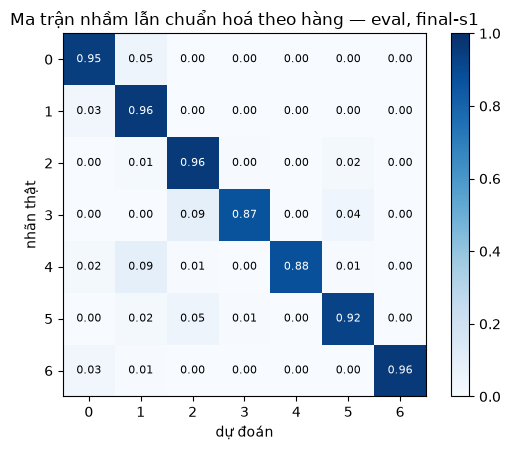

In [18]:
# Phân tích lỗi theo lớp trên eval (số lấy từ eval_result.json; hàng = nhãn thật, cột = dự đoán)
CLASS = ["0 Spruce/Fir", "1 Lodgepole Pine", "2 Ponderosa Pine", "3 Cottonwood/Willow", "4 Aspen", "5 Douglas-fir", "6 Krummholz"]
er = json.load(open(f"{OUT_DIR}/eval_result.json"))
pc = pd.DataFrame(er["per_class"]).set_index("cls"); pc.insert(0, "tên", [c[2:] for c in CLASS])
pc["baseline_f1"] = [d["f1"] for d in EVAL["base-s1"]["per_class"]]
display(pc.round(4))
cm = np.array(er["confusion_matrix"])
display(pd.DataFrame(cm, index=[f"thật {i}" for i in range(7)], columns=[f"đoán {i}" for i in range(7)]))
print("Với mỗi lớp thật: hai lớp bị đoán nhầm sang nhiều nhất (tỉ lệ trên support của lớp thật)")
for c in range(7):
    row = cm[c].astype(float).copy(); row[c] = 0; top = row.argsort()[::-1][:2]
    print(f"  lớp {c} (support {cm[c].sum():>6}, recall {cm[c, c] / cm[c].sum():.3f}): " + ", ".join(f"→ lớp {j}: {int(row[j])} ({row[j] / cm[c].sum():.1%})" for j in top))
print("Với mỗi lớp được đoán: nguồn dương tính giả lớn nhất")
for c in range(7):
    col = cm[:, c].astype(float).copy(); col[c] = 0; j = int(col.argmax())
    print(f"  đoán {c} (precision {cm[c, c] / cm[:, c].sum():.3f}): {int(col[j])} mẫu thật là lớp {j} ({col[j] / cm[:, c].sum():.1%} số lần đoán {c})")
fig, ax = plt.subplots(figsize=(5.6, 4.6))
im = ax.imshow(cm / cm.sum(1, keepdims=True), cmap="Blues", vmin=0, vmax=1)
for i in range(7):
    for j in range(7):
        v = cm[i, j] / cm[i].sum(); ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8, color="white" if v > 0.5 else "black")
ax.set_xlabel("dự đoán"); ax.set_ylabel("nhãn thật"); ax.set_title(f"Ma trận nhầm lẫn chuẩn hoá theo hàng — eval, {SUBMIT_ID}")
fig.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

**Phân tích lỗi.** Số lấy từ `eval_result.json` (`final-s1`): accuracy 0,9543, macro-F1 **0,9329**; baseline `base-s1` trên eval: 0,9087 và 0,8563. Val và eval sát nhau (val − eval = −0,0026 với `final-s1`, −0,0050 với `base-s1`).
- **Lớp khó nhất: lớp 3 (Cottonwood/Willow), F1 = 0,8848**, cũng là lớp hiếm nhất (549 mẫu eval, 0,47%). Recall 0,867: 49 mẫu (8,9%) bị đoán thành lớp 2 (Ponderosa Pine) và 24 mẫu (4,4%) thành lớp 5 (Douglas-fir); không mẫu nào bị nhầm sang lớp 0, 1, 4, 6. Kế đến là **lớp 4 (Aspen), F1 = 0,8898**, recall 0,876: 176 mẫu (9,3%) bị đoán thành lớp 1 (Lodgepole Pine).
- **Về số lượng tuyệt đối**, lỗi tập trung ở cặp 0 ↔ 1: 2 033 mẫu lớp 0 bị đoán thành 1 và 1 803 mẫu lớp 1 thành 0, tổng 3 836 trên 5 306 lỗi (72%). Hai lớp này chiếm 85% dữ liệu nên chúng quyết định accuracy, nhưng F1 của chúng vẫn cao (0,951 và 0,961).
- Ma trận nhầm lẫn gần như chia khối: nhóm {0, 1, 4, 6} nhầm lẫn nhau, nhóm {2, 3, 5} nhầm lẫn nhau, rất ít nhầm chéo (lớp 3 và 6 không nhầm nhau mẫu nào).
- **Lý giải (giả thuyết, chưa có thí nghiệm kiểm chứng):** (1) mất cân bằng: cross-entropy không trọng số để mỗi mẫu đóng góp như nhau, nên ở vùng chồng lấn mô hình nghiêng về lớp đông hơn (Aspen bị hút về Lodgepole Pine, lớn gấp 30 lần); (2) hai khối nhầm lẫn gợi ý các lớp trong cùng khối có đặc trưng địa hình gần nhau (tôi đoán là độ cao và loại đất), nhưng tôi chưa xem phân phối đặc trưng theo lớp để xác nhận.
- **So với baseline:** các lớp nhỏ được lợi nhiều nhất: lớp 4 từ 0,7485 lên 0,8898, lớp 5 từ 0,8012 lên 0,9226, lớp 3 từ 0,7945 lên 0,8848; lớp 0 và 1 tăng ~0,04. Đó là lý do macro-F1 tăng (+0,0766) nhiều hơn accuracy (+0,0456).
- **Sẽ thử tiếp:** cross-entropy có trọng số theo lớp (hoặc lấy mẫu cân bằng), chọn bằng val macro-F1, rồi xem recall lớp 3 và 4 có tăng mà không làm mất precision của lớp 1 và 2.

In [19]:
# Bảng experiments.xlsx từ results/*.json (không gõ tay). eval_acc / eval_macro_f1 chỉ điền cho baseline và mô hình nộp.
SUMMARY_NOTES = {
    "baseline": "3 seed ở lr=0.3: val macro-F1 0.8563 ± 0.0048 (2σ = 0.0095); best epoch 19–20, chưa hội tụ, khoảng cách val−train ≈ 0.025.",
    "loss": "MSE thấp hơn CE 0.0675 macro-F1 (vượt 2σ) và hội tụ chậm hơn; lr chưa dò lại cho MSE.",
    "optimizer": "Ở lr tốt nhất: Adam 0.8835 > AdamW 0.8702 > SGD+momentum 0.8513 > SGD 0.7746. Adam hơn baseline +0.027 (vượt 2σ). lr tốt nhất của SGD, Adam, AdamW đều ở mép trên của lưới.",
    "hparam": "lr tốt 0.1–0.3 (0.01 chậm, 1.0 dao động). Batch 128 và batch 2048+lr×4 kém vì lr quá lớn so với lô; M-wide +0.023 (vượt 2σ), M-deep trong nhiễu.",
    "dropout": "Baseline chưa quá khớp; dropout 0.1/0.3/0.5 làm macro-F1 giảm đơn điệu (−0.016/−0.093/−0.187) do train loss tăng.",
    "clipping": "c=0.34 ở lr baseline: clip 76.5% số bước, kết quả trong nhiễu. lr=3.0: không clip thì sụp về lớp đa số (gai gradient 294); có clip chặn gai (4.2) nhưng không cứu được.",
    "amp": "FP16/BF16 cho macro-F1 trong nhiễu so với FP32; không có bằng chứng nhanh hơn với M-base (thời gian trôi giữa các lần chạy); chỉ nhanh hơn ~2× khi độ rộng ≥ 4096.",
    "init": "zeros kẹt ở lớp đa số (chỉ b3 có gradient). normal/xavier/default/he tương đương trong nhiễu: mạng 3 lớp không đủ sâu để thấy khác biệt.",
    "final": "Adam lr=3e-3 + M-wide + 40 epoch + cosine: val macro-F1 0.9303 ± 0.0007 (3 seed), +0.074 so với baseline. Nộp final-s1: eval macro-F1 0.9329, acc 0.9543."
}
results = load_results(f"{OUT_DIR}/results")
rows = sort_rows([to_row(r, eval_scores=EVAL.get(r["cfg"]["exp_id"]),
                         notes=("MÔ HÌNH NỘP (predictions_eval.csv), seed 1" if r["cfg"]["exp_id"] == SUBMIT_ID else "")) for r in results])
write_xlsx(rows, f"{REPO_ROOT}/templates/experiment_table_template.xlsx", f"{OUT_DIR}/experiments.xlsx",
           seed_ids=BASE_IDS, summary_notes=SUMMARY_NOTES)
figs = {f[:-4] for f in os.listdir(f"{OUT_DIR}/figures") if f.endswith(".png") and not f.startswith("compare_")}
ids = {r["exp_id"] for r in rows}
print(f"số dòng trong bảng: {len(rows)} | số ảnh figures/<exp_id>.png: {len(figs)} | khớp tên: {figs == ids}")
assert figs == ids and len(ids) == len(rows)
print("số dòng theo nhóm:", pd.Series([r["group"] for r in rows]).value_counts().to_dict())
print("đã ghi", os.path.abspath(f"{OUT_DIR}/experiments.xlsx"), "(mở bằng Excel/LibreOffice để công thức tính lại)")

số dòng trong bảng: 38 | số ảnh figures/<exp_id>.png: 38 | khớp tên: True
số dòng theo nhóm: {'hparam': 10, 'optimizer': 9, 'init': 4, 'baseline': 3, 'dropout': 3, 'clipping': 3, 'final': 3, 'amp': 2, 'loss': 1}
đã ghi C:\Users\Admin\OneDrive\Desktop\AI20K\Track4\K4-Track4-Day1-Neuralnetwork\submission_2A202602571\experiments.xlsx (mở bằng Excel/LibreOffice để công thức tính lại)


**Kết thúc.** Sản phẩm trong `submission_2A202602571/`: `REPORT.md`, `experiments.xlsx`, `predictions_eval.csv`, `eval_result.json`, `figures/`, `results/`, `code/`. Mô hình nộp: seed 1 của cấu hình cuối cùng, trọng số tại epoch có val loss thấp nhất.